<a href="https://colab.research.google.com/github/Gabriel-Leite-Py/LiverDiseaseDiagnosis_SNC/blob/main/SNC_Liver_2024.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# This code is intended to create graphical reports and studies on the data for the SPRINGER article for the OL2A 2024 conference.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats


pd.set_option('future.no_silent_downcasting', True)

df = pd.read_excel('Indian Liver Patient Dataset (ILPD).xlsx')

df['Gender'] = df['Gender'].replace({'Female': 0, 'Male': 1})
df['Selector'] = df['Selector'].replace({2: 0, 1: 1})
df_selector = df['Selector']

In [2]:
df

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,AGRatio,Selector
0,65,0,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,1,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,1,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,1,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,1,3.9,2.0,195,27,59,7.3,2.4,0.40,1
...,...,...,...,...,...,...,...,...,...,...,...
578,60,1,0.5,0.1,500,20,34,5.9,1.6,0.37,0
579,40,1,0.6,0.1,98,35,31,6.0,3.2,1.10,1
580,52,1,0.8,0.2,245,48,49,6.4,3.2,1.00,1
581,31,1,1.3,0.5,184,29,32,6.8,3.4,1.00,1


In [3]:
FILL_METHOD = 'polynomial'

df_cleaned = df.copy()

if FILL_METHOD == 'linear':
    from sklearn.linear_model import LinearRegression
    train_data = df_cleaned.dropna()
    X = train_data[['ALB']]
    y = train_data['AGRatio']
    model = LinearRegression()
    model.fit(X, y)
    df_cleaned['AGRatio'] = df_cleaned.apply(
        lambda row: model.predict([[row['ALB']]])[0] if pd.isnull(row['AGRatio']) else row['AGRatio'], axis=1
    )
elif FILL_METHOD == 'polynomial':
    from sklearn.preprocessing import PolynomialFeatures
    from sklearn.linear_model import LinearRegression
    train_data = df_cleaned.dropna()
    X = train_data[['ALB']]
    y = train_data['AGRatio']
    poly = PolynomialFeatures(degree=2)
    X_poly = poly.fit_transform(X)
    model = LinearRegression()
    model.fit(X_poly, y)
    def predict(row):
        if pd.isnull(row['AGRatio']):
            X_new = poly.transform([[row['ALB']]])
            return model.predict(X_new)[0]
        return row['AGRatio']
    df_cleaned['AGRatio'] = df_cleaned.apply(predict, axis=1)
# ... adicionar outros elif se desejar

# Salvar apenas o dataframe final
df_cleaned.to_excel('Dados_Tratados.xlsx', index=False)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


# Outliers

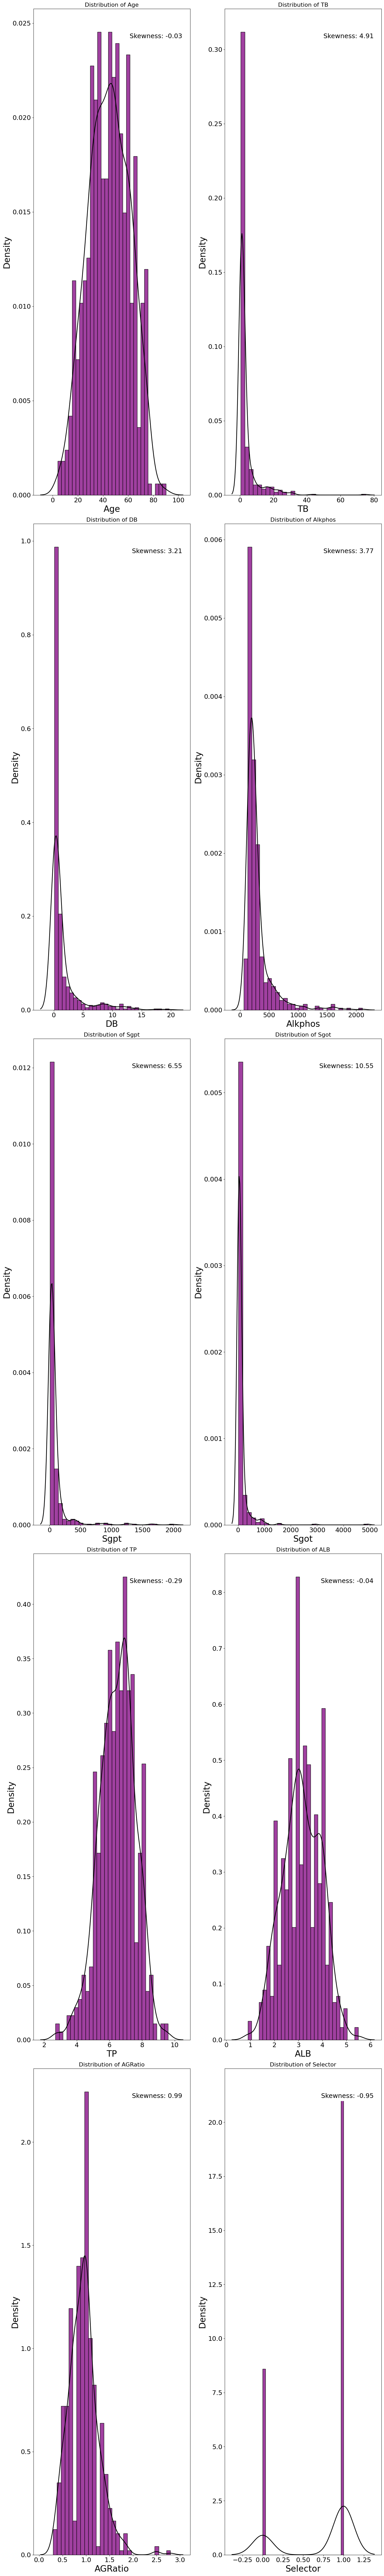

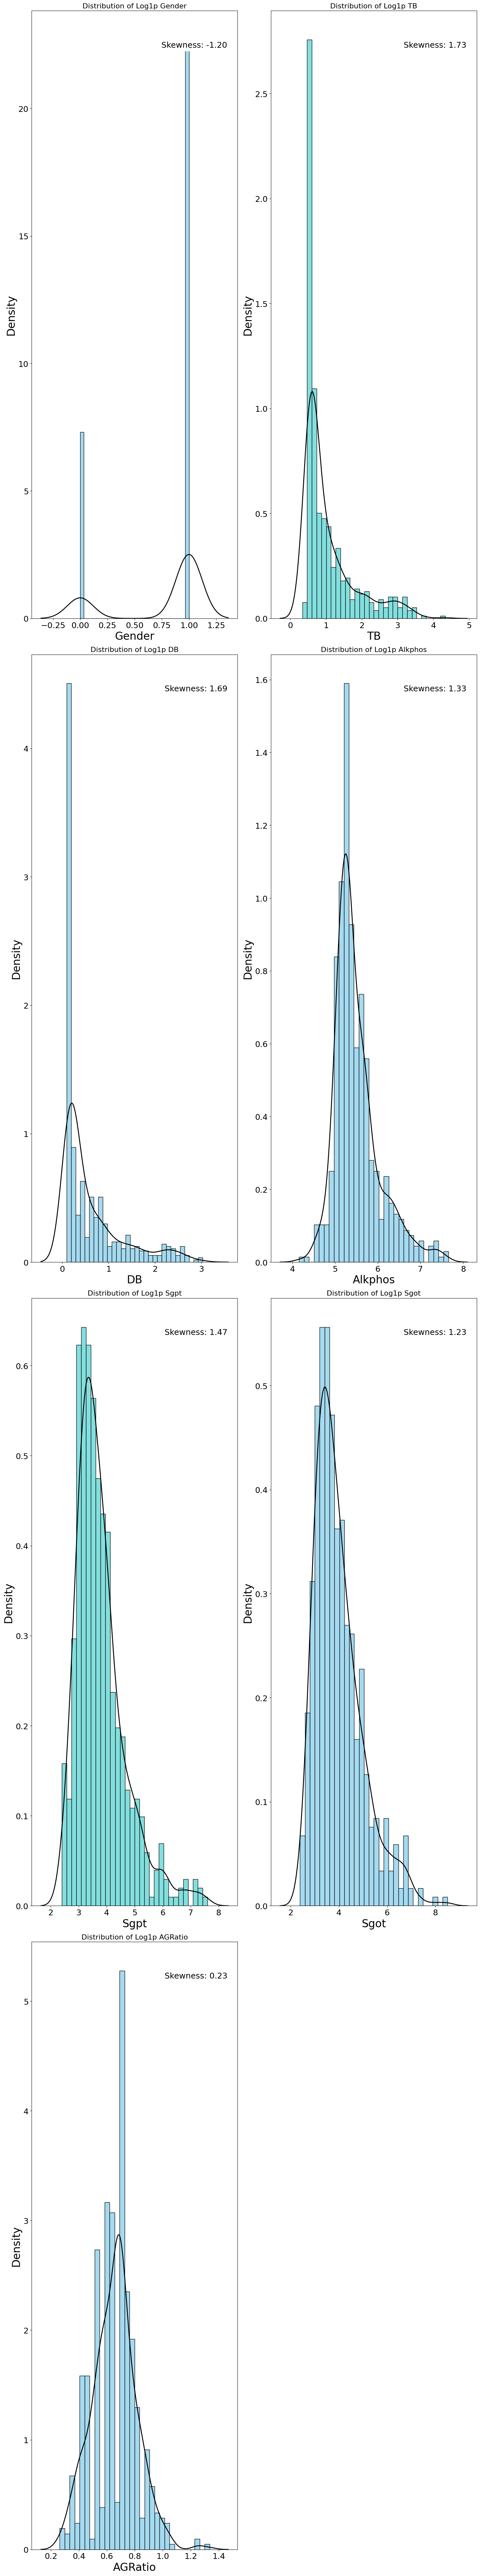

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------------------------
# Função auxiliar para plotar distribuições de múltiplas colunas
# -------------------------------------------------------------------
def plot_distributions(df, columns=None, ncols=2, figsize=(15, 5),
                       title_fontsize=16, axis_fontsize=20, tick_fontsize=18,
                       color='skyblue', show_skewness=True, title_prefix=''):
    """
    Plota histograma + KDE para as colunas especificadas (ou todas numéricas).

    Parameters:
    df : DataFrame
    columns : list, opcional. Lista de colunas a plotar. Se None, usa todas as numéricas.
    ncols : int, número de colunas do grid de subplots.
    figsize : tuple, tamanho da figura.
    title_fontsize, axis_fontsize, tick_fontsize : int
    color : str ou dict, cor(es) dos histogramas. Se dict, mapeia coluna -> cor.
    show_skewness : bool, se True exibe o valor de skewness no canto superior direito.
    title_prefix : str, prefixo para o título (ex: 'Original' ou 'Log1p').
    """
    if columns is None:
        columns = df.select_dtypes(include=[np.number]).columns.tolist()

    nrows = int(np.ceil(len(columns) / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(figsize[0], nrows * figsize[1]))
    axes = axes.flatten() if nrows * ncols > 1 else [axes]

    for i, col in enumerate(columns):
        ax = axes[i]
        data = df[col].dropna()

        # Define cor
        if isinstance(color, dict):
            hist_color = color.get(col.lower(), 'skyblue')
        else:
            hist_color = color

        # Histograma + KDE
        sns.histplot(data, ax=ax, color=hist_color, kde=False, bins=30, stat='density')
        sns.kdeplot(data, ax=ax, color='black', linewidth=2)

        # Skewness
        if show_skewness and len(data) > 0:
            skew_val = data.skew()
            ax.text(0.95, 0.95, f'Skewness: {skew_val:.2f}',
                    horizontalalignment='right', verticalalignment='top',
                    transform=ax.transAxes, fontsize=tick_fontsize,
                    bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.3'))

        # Títulos e labels
        title = f'{title_prefix} {col}'.strip() if title_prefix else col
        ax.set_title(f'Distribution of {title}', fontsize=title_fontsize)
        ax.set_xlabel(col, fontsize=axis_fontsize)
        ax.set_ylabel('Density', fontsize=axis_fontsize)
        ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)

    # Remove eixos extras
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


# -------------------------------------------------------------------
# Função para aplicar log1p e visualizar transformação
# -------------------------------------------------------------------
def apply_log1p_and_plot(df, columns_to_transform, colors=None, **plot_kwargs):
    """
    Aplica np.log1p nas colunas especificadas, plota as distribuições transformadas,
    e retorna o DataFrame com as colunas transformadas.

    Parameters:
    df : DataFrame
    columns_to_transform : list, colunas a serem transformadas (devem ser numéricas).
    colors : dict ou str, cores para os histogramas.
    **plot_kwargs : argumentos adicionais para plot_distributions.

    Returns:
    df_transformed : DataFrame com as colunas transformadas.
    """
    df_trans = df.copy()
    for col in columns_to_transform:
        if col in df_trans.columns and pd.api.types.is_numeric_dtype(df_trans[col]):
            df_trans[col] = np.log1p(df_trans[col])

    # Plota distribuições transformadas
    plot_distributions(df_trans, columns=columns_to_transform,
                       color=colors if colors else 'skyblue',
                       title_prefix='Log1p', show_skewness=True, **plot_kwargs)
    return df_trans


# -------------------------------------------------------------------
# Uso no seu pipeline
# -------------------------------------------------------------------
# 1. Plot original
plot_distributions(df_cleaned, ncols=2, figsize=(15, 20), color='purple',
                   title_fontsize=16, axis_fontsize=24, tick_fontsize=18)

# 2. Definir colunas assimétricas a serem transformadas
skewed_cols = ['Gender', 'TB', 'DB', 'Alkphos', 'Sgpt', 'Sgot', 'AGRatio']

# Cores personalizadas (opcional)
custom_colors = {'sgpt': '#5AD5D4', 'tb': '#5AD5D4'}

# 3. Aplicar log1p, plotar e obter DataFrame transformado
df_cleaned_log = apply_log1p_and_plot(df_cleaned, skewed_cols,
                                       colors=custom_colors,
                                       ncols=2, figsize=(15, 20),
                                       title_fontsize=16, axis_fontsize=24, tick_fontsize=18)

# Feature Selection

<Figure size 1000x800 with 0 Axes>

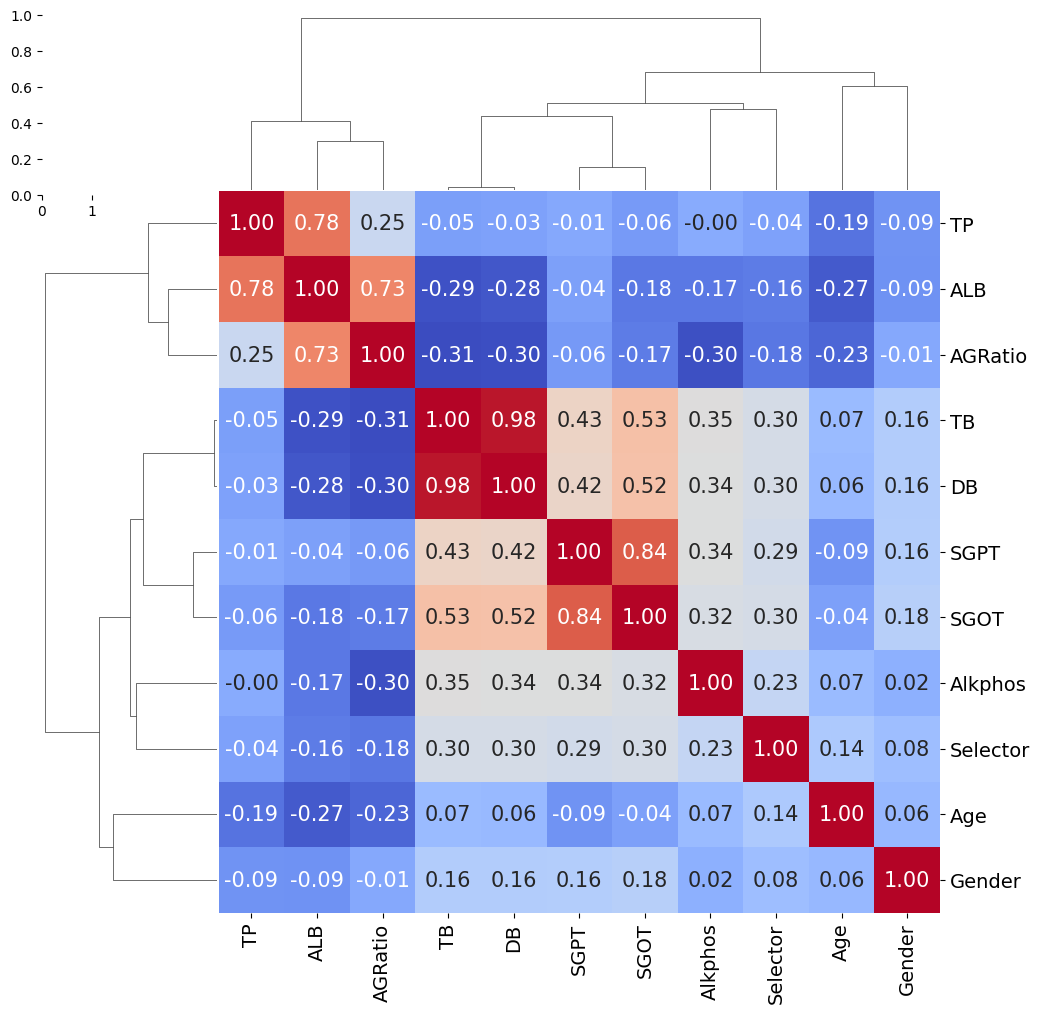

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
df_cleaned_log = df_cleaned_log.rename(columns={"Sgpt":"SGPT","Sgot":"SGOT"})

columns = df_cleaned_log.columns.tolist()
if 'Selector' in columns:
    columns.remove('Selector')
    columns.append('Selector')
    df_cleaned_log = df_cleaned_log[columns]

correlation_matrix = df_cleaned_log.corr()

correlation_matrix = correlation_matrix.reindex(columns, axis=0).reindex(columns, axis=1)

plt.figure(figsize=(10, 8))
clustermap = sns.clustermap(correlation_matrix, annot=True, fmt='.2f', annot_kws={"size": 15}, cbar=False, cmap="coolwarm")
clustermap.ax_heatmap.set_xticklabels(clustermap.ax_heatmap.get_xmajorticklabels(), fontsize = 14)
clustermap.ax_heatmap.set_yticklabels(clustermap.ax_heatmap.get_ymajorticklabels(), fontsize = 14)
plt.show()

In [6]:
features_list = ['DB', 'Age', 'Gender', 'Alkphos', 'SGOT', 'ALB', 'AGRatio']
X = df_cleaned_log[features_list]
y = df_cleaned_log['Selector']

In [ ]:
# -------------------------------------------------------------------
# RFECV with Multiple Models - Voting for Feature Importance
# -------------------------------------------------------------------
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from sklearn.feature_selection import RFECV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import Perceptron
from sklearn.preprocessing import MinMaxScaler

# ============================
# SET RANDOM SEED FOR REPRODUCIBILITY
# ============================
RANDOM_STATE = 42


# ============================
# MODELS TO TEST (WITH RANDOM_STATE)
# ============================
models = {
    'DecisionTree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(random_state=RANDOM_STATE),
    'GradientBoosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_STATE),
    'LightGBM': LGBMClassifier(random_state=RANDOM_STATE, verbose=-1),
    'Perceptron': Perceptron(max_iter=1000, random_state=RANDOM_STATE)
}

# ============================
# RESULTS DATAFRAME
# ============================
results = pd.DataFrame({'Feature': X.columns})

print("=" * 60)
print("RUNNING RFECV FOR MULTIPLE MODELS")
print("=" * 60)

for model_name, model in models.items():
    print(f"\nRunning {model_name}...")

    # Scale data (MinMaxScaler)
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)

    # Set importance getter based on model type
    if model_name in ['DecisionTree', 'RandomForest', 'GradientBoosting', 'XGBoost', 'LightGBM']:
        importance_getter = 'feature_importances_'
    else:
        importance_getter = 'coef_'

    rfecv = RFECV(
        estimator=model,
        step=1,
        min_features_to_select=3,
        cv=10,
        scoring='accuracy',
        importance_getter=importance_getter,
        n_jobs=-1
    )

    rfecv.fit(X_scaled, y)
    results[model_name] = rfecv.support_.astype(int)
    print(f"  Selected {rfecv.n_features_} features: {list(X.columns[rfecv.support_])}")

# ============================
# RESULTS
# ============================
results['Total_Votes'] = results.iloc[:, 1:].sum(axis=1)
results = results.sort_values('Total_Votes', ascending=False)

print("\n" + "=" * 60)
print("FINAL RESULTS (SORTED BY TOTAL VOTES)")
print("=" * 60)
print(results.to_string(index=False))

# ============================
# VISUALIZATION
# ============================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar plot of total votes
colors = ['green' if v >= len(models)/2 else 'orange' if v >= len(models)/3 else 'red'
          for v in results['Total_Votes']]
axes[0].barh(results['Feature'], results['Total_Votes'], color=colors)
axes[0].axvline(x=len(models)/2, color='blue', linestyle='--', label=f'Majority ({len(models)//2 + 1} votes)')
axes[0].set_xlabel('Number of Votes')
axes[0].set_title('Feature Votes Across Models')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Heatmap of selections
import seaborn as sns
heatmap_data = results.set_index('Feature').drop('Total_Votes', axis=1).T
sns.heatmap(heatmap_data, annot=True, cbar=False, cmap='RdYlGn', ax=axes[1])
axes[1].set_title('Feature Selection by Model')
axes[1].set_xlabel('Feature')
axes[1].set_ylabel('Model')

plt.tight_layout()
plt.show()

# ============================
# SELECTED FEATURES
# ============================
# Features with majority vote (> 50% of models)
majority_threshold = len(models) // 2 + 1
selected_features = results[results['Total_Votes'] >= majority_threshold]['Feature'].tolist()

print("\n" + "=" * 60)
print(f"SELECTED FEATURES (>= {majority_threshold} votes)")
print("=" * 60)
print(f"Features: {selected_features}")
print(f"Number of selected features: {len(selected_features)}")

# Save results
results.to_excel('feature_selection_voting.xlsx', index=False)
print("\nResults saved to 'feature_selection_voting.xlsx'")

In [8]:
results.to_excel('FeatureSelectionRFECV.xlsx')

# K-Value

OPTIMAL k DETERMINATION
Silhouette Score suggests k = 2
Davies-Bouldin Index suggests k = 6
Calinski-Harabasz Index suggests k = 2
VOTED optimal k = 2


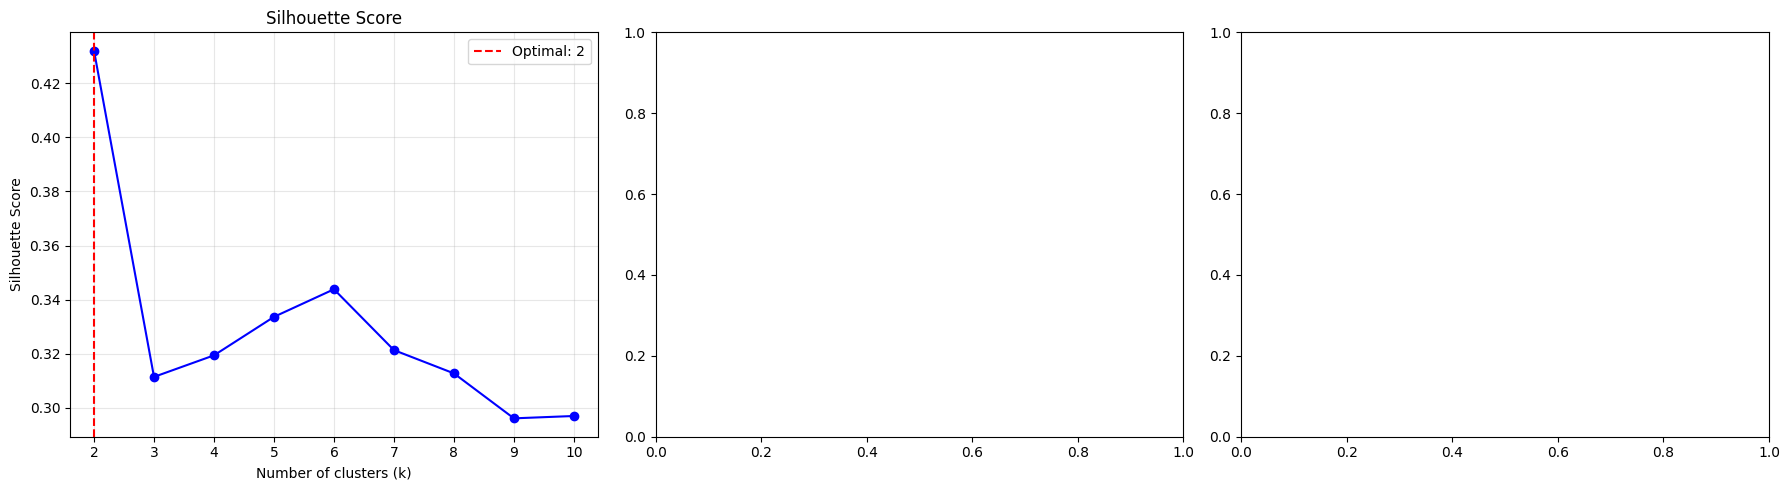

In [9]:
# -------------------------------------------------------------------
# Optimal k Determination for K-Means Clustering
# -------------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# ============================
# ADJUSTABLE SETTINGS
# ============================
# Features to use for clustering (must be present in df)
CLUSTER_FEATURES = ['Age', 'Alkphos', 'DB']
MIN_K = 2
MAX_K = 10
RANDOM_STATE = 42

# ============================
# DATA PREPARATION
# ============================
# Assuming df_cleaned is the processed DataFrame (after cleaning, log1p, etc.)
# Filter only positive cases (Selector == 1)
df_pos = df_cleaned_log[df_cleaned_log['Selector'] == 1][CLUSTER_FEATURES].copy()
df_pos.reset_index(drop=True, inplace=True)

# Standardize features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df_pos)

# ============================
# EVALUATION LOOP
# ============================
k_values = list(range(MIN_K, MAX_K + 1))
silhouette = []
davies_bouldin = []
calinski_harabasz = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = kmeans.fit_predict(X_scaled)

    silhouette.append(silhouette_score(X_scaled, labels))
    davies_bouldin.append(davies_bouldin_score(X_scaled, labels))
    calinski_harabasz.append(calinski_harabasz_score(X_scaled, labels))

# ============================
# OPTIMAL k DETERMINATION
# ============================
optimal_silhouette = k_values[np.argmax(silhouette)]
optimal_davies = k_values[np.argmin(davies_bouldin)]
optimal_calinski = k_values[np.argmax(calinski_harabasz)]

# Voting (simple majority among the three metrics)
from collections import Counter
votes = Counter([optimal_silhouette, optimal_davies, optimal_calinski])
optimal_k_voted = votes.most_common(1)[0][0]

print("=" * 50)
print("OPTIMAL k DETERMINATION")
print("=" * 50)
print(f"Silhouette Score suggests k = {optimal_silhouette}")
print(f"Davies-Bouldin Index suggests k = {optimal_davies}")
print(f"Calinski-Harabasz Index suggests k = {optimal_calinski}")
print(f"VOTED optimal k = {optimal_k_voted}")
print("=" * 50)

# ============================
# VISUALIZATION
# ============================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))


# Silhouette Score
axes[0].plot(k_values, silhouette, marker='o', linestyle='-', color='b')
axes[0].axvline(x=optimal_silhouette, color='r', linestyle='--', label=f'Optimal: {optimal_silhouette}')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Silhouette Score')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
"""
# Davies-Bouldin Index
axes[1].plot(k_values, davies_bouldin, marker='s', linestyle='-', color='g')
axes[1].axvline(x=optimal_davies, color='r', linestyle='--', label=f'Optimal: {optimal_davies}')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Davies-Bouldin Index')
axes[1].set_title('Davies-Bouldin Index (lower is better)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Calinski-Harabasz Index
axes[2].plot(k_values, calinski_harabasz, marker='^', linestyle='-', color='m')
axes[2].axvline(x=optimal_calinski, color='r', linestyle='--', label=f'Optimal: {optimal_calinski}')
axes[2].set_xlabel('Number of clusters (k)')
axes[2].set_ylabel('Calinski-Harabasz Index')
axes[2].set_title('Calinski-Harabasz Index')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
"""
plt.tight_layout()
plt.show()

# Fuzzy c-means

In [10]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 24.6 MB/s eta 0:00:00


In [11]:
# -------------------------------------------------------------------
# Plotting Function - Exact Style Match
# -------------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from matplotlib.lines import Line2D

def plot_clusters_fuzzy_style(df_data, centroids_array, feature_cols, cluster_col='Cluster',
                              title_prefix='', figsize=(16, 6)):
    """
    Creates pairwise scatter plots with cluster ellipses and centroids.
    Matches the exact style of the original code.

    Parameters:
    -----------
    df_data : pd.DataFrame
        DataFrame containing feature columns and cluster assignment column.
    centroids_array : np.ndarray
        Array of centroids with shape (n_clusters, n_features).
    feature_cols : list
        List of feature column names (e.g., ['Age', 'Alkphos', 'DB']).
    cluster_col : str
        Name of the column containing cluster labels.
    title_prefix : str
        Prefix for plot titles (e.g., 'Scaled', 'Original').
    figsize : tuple
        Figure size (width, height).
    """
    n_features = len(feature_cols)
    n_clusters = centroids_array.shape[0]

    # Create figure and axes (3 combinations for 3 features)
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    axes = axes.ravel()

    combinations = [(0, 1), (0, 2), (1, 2)]

    colors = ['blue', 'black', 'purple', 'green', 'orange', 'red', "yellow","brown","gray","cyan"]

    for i, (x_index, y_index) in enumerate(combinations):
        ax = axes[i]
        x_col = feature_cols[x_index]
        y_col = feature_cols[y_index]

        for j in range(n_clusters):
            # Get cluster data
            cluster_data = df_data.loc[df_data[cluster_col] == j, [x_col, y_col]].values

            # Scatter plot
            ax.scatter(cluster_data[:, 0], cluster_data[:, 1], s=30,
                      label=f'Cluster {j}', color=colors[j])

            # Plot centroid
            ax.scatter(centroids_array[j, x_index], centroids_array[j, y_index],
                      marker='D', color='black', s=100)

            # Draw confidence ellipse (95% confidence)
            cluster_center = centroids_array[j, [x_index, y_index]]

            if cluster_data.shape[0] > 1:
                cov_matrix = np.cov(cluster_data.T)
                eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
                order = eigenvalues.argsort()[::-1]
                eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]
                angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))

                ell = Ellipse(xy=cluster_center,
                              width=2 * np.sqrt(5.991 * eigenvalues[0]),
                              height=2 * np.sqrt(5.991 * eigenvalues[1]),
                              angle=angle,
                              edgecolor=colors[j],
                              lw=2,
                              fill=False)
                ax.add_patch(ell)

        # Legend for centroids only
        legend_elements = [
            Line2D([0], [0], marker='D', color='w', markerfacecolor='black',
                   markersize=12, label='Centroids'),
        ]
        ax.legend(handles=legend_elements, loc='upper right')

        # Title and labels
        title = f'{title_prefix}: {x_col} vs {y_col}'.strip()
        ax.set_title(title, fontsize=14)
        ax.set_xlabel(x_col, fontsize=16)
        ax.set_ylabel(y_col, fontsize=16)

    plt.tight_layout()
    plt.show()


def plot_fuzzy_clusters_both_scales(df_scaled, df_original, cntr_scaled, cntr_original,
                                    feature_cols, n_clusters):
    """
    Plots clusters for both scaled and original data.

    Parameters:
    -----------
    df_scaled : pd.DataFrame
        Scaled data with 'Cluster' column.
    df_original : pd.DataFrame
        Original scale data with 'Cluster' column.
    cntr_scaled : np.ndarray
        Centroids in scaled space (shape: n_clusters x n_features).
    cntr_original : np.ndarray
        Centroids in original space (shape: n_clusters x n_features).
    feature_cols : list
        List of feature column names.
    n_clusters : int
        Number of clusters.
    """
    print("=" * 50)
    print("SCALED DATA CLUSTERS")
    print("=" * 50)
    plot_clusters_fuzzy_style(
        df_data=df_scaled,
        centroids_array=cntr_scaled,
        feature_cols=feature_cols,
        cluster_col='Cluster',
        title_prefix='Scaled',
        figsize=(16, 6)
    )

    print("\n" + "=" * 50)
    print("ORIGINAL SCALE CLUSTERS")
    print("=" * 50)
    plot_clusters_fuzzy_style(
        df_data=df_original,
        centroids_array=cntr_original,
        feature_cols=feature_cols,
        cluster_col='Cluster',
        title_prefix='Original',
        figsize=(16, 6)
    )

In [12]:
# -------------------------------------------------------------------
# Complete Wrapper Function - Both Scales
# -------------------------------------------------------------------
def plot_fuzzy_clusters_complete(df_scaled, df_original, cntr_scaled, df_centroids_original,
                                  feature_cols, n_clusters):
    """
    Plots clusters for both scaled and original data using the exact original styles.

    Parameters:
    -----------
    df_scaled : pd.DataFrame
        Scaled data with 'Cluster' column.
    df_original : pd.DataFrame
        Original scale data with 'Cluster' column.
    cntr_scaled : np.ndarray
        Centroids in scaled space (shape: n_clusters x n_features).
    df_centroids_original : pd.DataFrame
        Centroids in original space as DataFrame with 'Cluster' column.
    feature_cols : list
        List of feature column names (e.g., ['Age', 'Alkphos', 'DB']).
    n_clusters : int
        Number of clusters.
    """
    # ============================
    # SCALED DATA PLOT
    # ============================
    print("=" * 50)
    print("SCALED DATA CLUSTERS")
    print("=" * 50)

    fig, axes = plt.subplots(1, 3, figsize=(16, 6))
    axes = axes.ravel()

    combinations = [(0, 1), (0, 2), (1, 2)]
    colors = ['green', 'black', 'purple', 'blue', 'orange', 'red', "yellow","brown","gray","cyan"]

    for i, (x_index, y_index) in enumerate(combinations):
        ax = axes[i]
        x_col = feature_cols[x_index]
        y_col = feature_cols[y_index]

        for j in range(n_clusters):
            # Get cluster data
            cluster_data = df_scaled.loc[df_scaled['Cluster'] == j, [x_col, y_col]].values

            # Scatter plot
            ax.scatter(cluster_data[:, 0], cluster_data[:, 1], s=30,
                      label=f'Cluster {j}', color=colors[j])

            # Plot centroid (from array)
            ax.scatter(cntr_scaled[j, x_index], cntr_scaled[j, y_index],
                      marker='D', color='black', s=100)

            # Draw confidence ellipse
            cluster_center = cntr_scaled[j, [x_index, y_index]]

            if cluster_data.shape[0] > 1:
                cov_matrix = np.cov(cluster_data.T)
                eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
                order = eigenvalues.argsort()[::-1]
                eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]
                angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))

                ell = Ellipse(xy=cluster_center,
                              width=2 * np.sqrt(5.991 * eigenvalues[0]),
                              height=2 * np.sqrt(5.991 * eigenvalues[1]),
                              angle=angle,
                              edgecolor=colors[j],
                              lw=2,
                              fill=False)
                ax.add_patch(ell)

        legend_elements = [
            Line2D([0], [0], marker='D', color='w', markerfacecolor='black',
                   markersize=12, label='Centroids'),
        ]
        ax.legend(handles=legend_elements, loc='upper right')
        ax.set_title(f'Scaled: {x_col} vs {y_col}', fontsize=14)
        ax.set_xlabel(x_col, fontsize=16)
        ax.set_ylabel(y_col, fontsize=16)

    plt.tight_layout()
    plt.show()

    # ============================
    # ORIGINAL SCALE PLOT
    # ============================
    print("\n" + "=" * 50)
    print("ORIGINAL SCALE CLUSTERS")
    print("=" * 50)

    fig, axes = plt.subplots(1, 3, figsize=(16, 6))
    axes = axes.ravel()

    for i, (x_index, y_index) in enumerate(combinations):
        ax = axes[i]
        x_col = feature_cols[x_index]
        y_col = feature_cols[y_index]

        for j in range(n_clusters):
            # Get cluster data
            cluster_data = df_original.loc[df_original['Cluster'] == j, [x_col, y_col]].values

            # Scatter plot
            ax.scatter(cluster_data[:, 0], cluster_data[:, 1], s=30,
                      label=f'Cluster {j}', color=colors[j])

            # Get centroid coordinates from DataFrame
            centroid_x = df_centroids_original.loc[df_centroids_original['Cluster'] == j, x_col].values[0]
            centroid_y = df_centroids_original.loc[df_centroids_original['Cluster'] == j, y_col].values[0]

            # Plot centroid
            ax.scatter(centroid_x, centroid_y, marker='D', color='black', s=100)

            # Draw confidence ellipse
            if cluster_data.shape[0] > 1:
                cov_matrix = np.cov(cluster_data.T)
                eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
                order = eigenvalues.argsort()[::-1]
                eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]
                angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))

                ell = Ellipse(xy=(centroid_x, centroid_y),
                              width=2 * np.sqrt(5.991 * eigenvalues[0]),
                              height=2 * np.sqrt(5.991 * eigenvalues[1]),
                              angle=angle,
                              edgecolor=colors[j],
                              lw=2,
                              fill=False)
                ax.add_patch(ell)

        legend_elements = [
            Line2D([0], [0], marker='D', color='w', markerfacecolor='black',
                   markersize=12, label='Centroids'),
        ]
        ax.legend(handles=legend_elements, loc='upper right')
        ax.set_title(f'Original: {x_col} vs {y_col}', fontsize=14)
        ax.set_xlabel(x_col, fontsize=16)
        ax.set_ylabel(y_col, fontsize=16)

    plt.tight_layout()
    plt.show()

FUZZY C-MEANS RESULTS
Number of clusters: 6

Cluster counts:
Cluster
0    74
1    45
2    41
3    90
4    89
5    77
Name: count, dtype: int64

Centroids (original scale):
 Cluster       Age    Alkphos       DB
       0 66.291373 210.022884 0.397981
       1 40.283248 285.899695 8.723425
       2 57.646614 525.439414 3.293819
       3 47.187353 204.896864 0.290108
       4 27.987176 213.051401 0.292652
       5 44.427040 291.667551 1.488749
SCALED DATA CLUSTERS


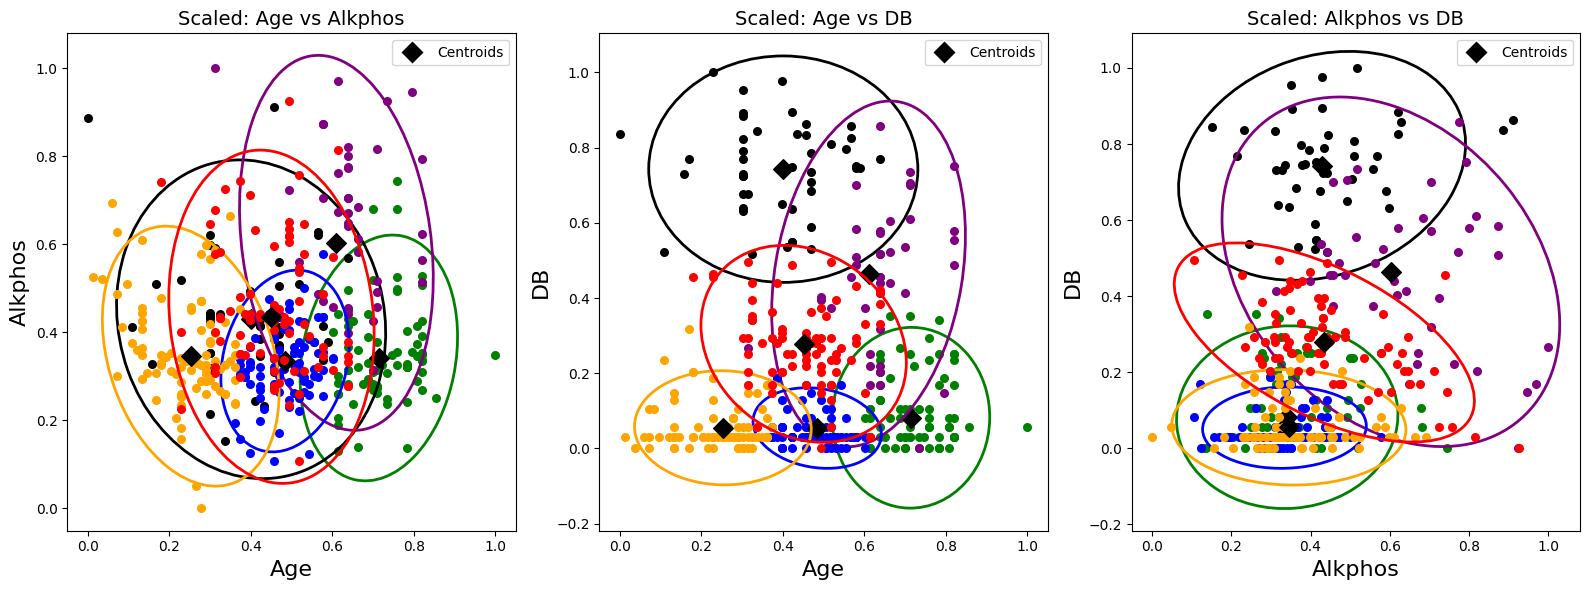


ORIGINAL SCALE CLUSTERS


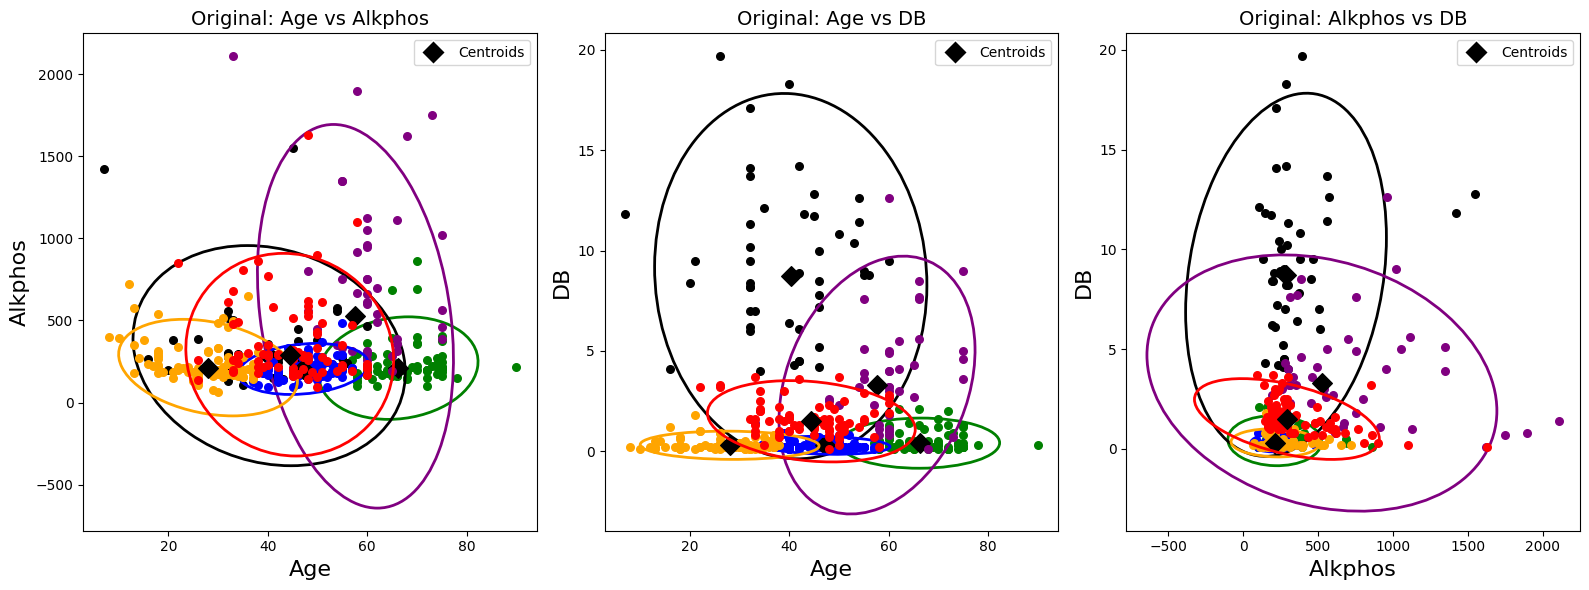

In [13]:
# -------------------------------------------------------------------
# Fuzzy C-Means Clustering (COMPLETE & CORRECTED)
# -------------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import skfuzzy as fuzz

# ============================
# CONFIGURATION
# ============================
CLUSTER_FEATURES = ['Age', 'Alkphos', 'DB']
N_CLUSTERS = 6
FUZZY_M = 2.0
ERROR = 0.005
MAXITER = 1000
RANDOM_STATE = 42

# ============================
# DATA PREPARATION
# ============================
# Assuming df_cleaned exists and contains the log-transformed columns
df_pos = df_cleaned_log[df_cleaned_log['Selector'] == 1][CLUSTER_FEATURES].copy()
df_pos.reset_index(drop=True, inplace=True)

# Scale features (store scalers for inverse transform later)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df_pos)
df_scaled = pd.DataFrame(X_scaled, columns=CLUSTER_FEATURES)

# ============================
# FUZZY C-MEANS
# ============================
cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
    df_scaled.T,
    c=N_CLUSTERS,
    m=FUZZY_M,
    error=ERROR,
    maxiter=MAXITER,
    init=None,
    seed=RANDOM_STATE
)

# Assign hard clusters (highest membership)
df_pos['Cluster'] = np.argmax(u, axis=0)

# ============================
# REVERSE TRANSFORMATIONS
# ============================
# 1. Inverse MinMax scaling to get back to log-space
cntr_log = scaler.inverse_transform(cntr)
df_centroids_log = pd.DataFrame(cntr_log, columns=CLUSTER_FEATURES)
df_centroids_log.index.name = 'Cluster'
df_centroids_log.reset_index(inplace=True)

# 2. Reverse log1p to get original scale
log_transformed_cols = ['Alkphos', 'DB']  # columns that were log1p-transformed
for col in log_transformed_cols:
    if col in df_pos.columns:
        df_pos[col] = np.expm1(df_pos[col])
    if col in df_centroids_log.columns:
        df_centroids_log[col] = np.expm1(df_centroids_log[col])

# ============================
# RESULTS
# ============================
print("=" * 50)
print("FUZZY C-MEANS RESULTS")
print("=" * 50)
print(f"Number of clusters: {N_CLUSTERS}")
print(f"\nCluster counts:\n{df_pos['Cluster'].value_counts().sort_index()}")
print(f"\nCentroids (original scale):\n{df_centroids_log.to_string(index=False)}")

# Save to Excel
df_pos.to_excel('fuzzy_results.xlsx', index=False)
df_centroids_log.to_excel('fuzzy_centroids.xlsx', index=False)

# ============================
# PREPARE DATA FOR PLOTTING
# ============================
# Add 'Cluster' column to df_scaled
df_scaled_plot = df_scaled.copy()
df_scaled_plot['Cluster'] = df_pos['Cluster'].values

# ============================
# GENERATE PLOTS
# ============================
plot_fuzzy_clusters_complete(
    df_scaled=df_scaled_plot,
    df_original=df_pos,
    cntr_scaled=cntr,                          # from fuzz.cluster.cmeans
    df_centroids_original=df_centroids_log,    # after inverse transform and expm1
    feature_cols=CLUSTER_FEATURES,
    n_clusters=N_CLUSTERS
)

MEMBERSHIP MATRIX (first 10 samples)
              Assigned_Cluster  Cluster_0  Cluster_1  Cluster_2  Cluster_3  \
Sample_Index                                                                 
0                            0   0.775029   0.009478   0.020020   0.124882   
1                            2   0.049003   0.126865   0.658594   0.042213   
2                            2   0.022209   0.040407   0.861590   0.018129   
3                            0   0.521935   0.012195   0.025615   0.321731   
4                            0   0.332489   0.076084   0.194292   0.140661   
5                            3   0.082135   0.014409   0.027880   0.582122   
6                            4   0.030910   0.013375   0.016671   0.105135   
7                            4   0.001859   0.000756   0.001049   0.007840   
8                            3   0.296674   0.016307   0.040284   0.456913   
9                            3   0.390592   0.012508   0.026431   0.441822   

              Cluster_4  C

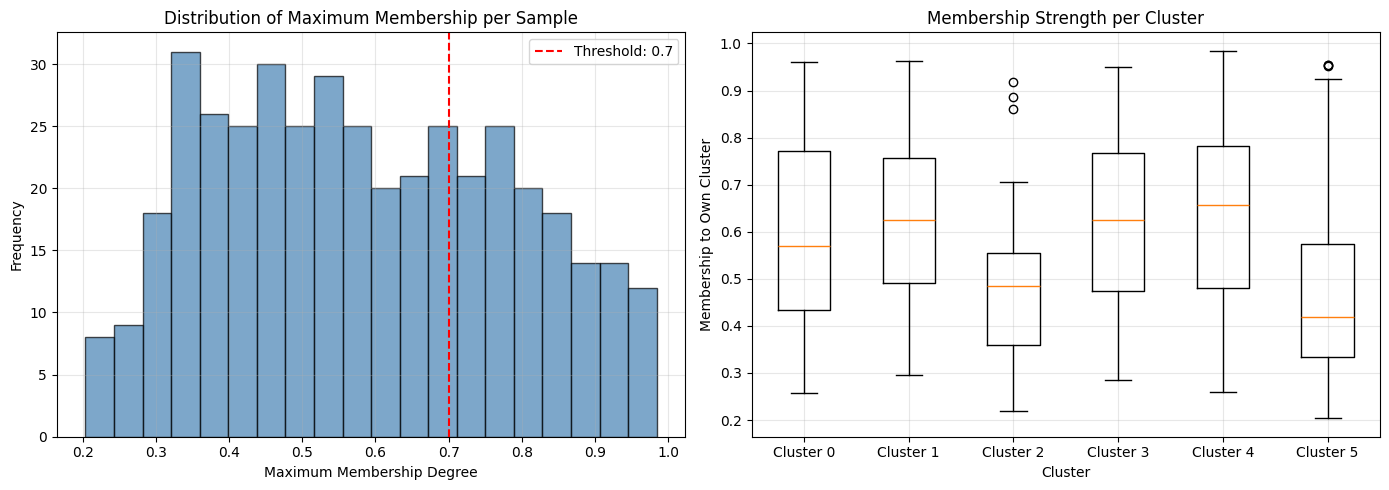

In [14]:
# -------------------------------------------------------------------
# Membership Matrix (Pertinence) Export
# -------------------------------------------------------------------
# u is the membership matrix from Fuzzy C-Means: shape (n_clusters, n_samples)
# u[i, j] = degree of membership of sample j to cluster i

# Create DataFrame with samples as rows and clusters as columns
membership_df = pd.DataFrame(
    data=u.T,  # transpose so rows = samples, columns = clusters
    columns=[f'Cluster_{i}' for i in range(N_CLUSTERS)]
)

# Add cluster assignment (hard cluster) for reference
membership_df.insert(0, 'Assigned_Cluster', df_pos['Cluster'].values)

# Add sample index for traceability
membership_df.index.name = 'Sample_Index'

print("=" * 50)
print("MEMBERSHIP MATRIX (first 10 samples)")
print("=" * 50)
print(membership_df.head(10))

print("\n" + "=" * 50)
print("MEMBERSHIP STATISTICS BY CLUSTER")
print("=" * 50)
for cluster in range(N_CLUSTERS):
    col = f'Cluster_{cluster}'
    cluster_members = membership_df[membership_df['Assigned_Cluster'] == cluster]
    print(f"\nCluster {cluster} (n={len(cluster_members)}):")
    print(f"  Mean membership to own cluster: {cluster_members[col].mean():.4f}")
    print(f"  Min membership to own cluster:  {cluster_members[col].min():.4f}")
    print(f"  Max membership to own cluster:  {cluster_members[col].max():.4f}")

# Identify "fuzzy" samples (max membership < 0.7)
fuzzy_threshold = 0.7
max_membership = membership_df[[f'Cluster_{i}' for i in range(N_CLUSTERS)]].max(axis=1)
fuzzy_samples = membership_df[max_membership < fuzzy_threshold]
print("\n" + "=" * 50)
print(f"SAMPLES WITH LOW MAX MEMBERSHIP (< {fuzzy_threshold})")
print("=" * 50)
if len(fuzzy_samples) > 0:
    print(f"Number of fuzzy samples: {len(fuzzy_samples)}")
    print(fuzzy_samples.head(10))
else:
    print("No samples with low max membership.")

# Export to Excel
membership_df.to_excel('fuzzy_membership_matrix.xlsx')
print("\nMembership matrix saved to 'fuzzy_membership_matrix.xlsx'")

# Optional: Visualize membership distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of max membership values
axes[0].hist(max_membership, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(x=fuzzy_threshold, color='red', linestyle='--', label=f'Threshold: {fuzzy_threshold}')
axes[0].set_xlabel('Maximum Membership Degree')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Maximum Membership per Sample')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Boxplot of membership to own cluster (for assigned cluster only)
own_membership = [membership_df.loc[membership_df['Assigned_Cluster'] == c, f'Cluster_{c}'].values
                  for c in range(N_CLUSTERS)]
axes[1].boxplot(own_membership, labels=[f'Cluster {c}' for c in range(N_CLUSTERS)])
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Membership to Own Cluster')
axes[1].set_title('Membership Strength per Cluster')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Combination of results from paper OL2A24 and the new results obtained

In [15]:
!git clone https://github.com/Gabriel-Leite-Py/LiverDiseaseDiagnosis_SNC

Cloning into 'LiverDiseaseDiagnosis_SNC'...
remote: Enumerating objects: 17, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 17 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (17/17), 1.96 MiB | 5.36 MiB/s, done.
Resolving deltas: 100% (3/3), done.


In [16]:
!mv LiverDiseaseDiagnosis_SNC/AllClusters.xlsx .

In [17]:
dataOl2A= pd.read_excel('AllClusters.xlsx')
jornalOl2A= pd.read_excel('fuzzy_results.xlsx')

In [18]:
dataOl2A.drop(columns=['Unnamed: 0'], inplace=True)
dataOl2A = dataOl2A[['Age','Alkphos','DB','Cluster Membership', 'IDS']].copy()
dataOl2A['IDS'] = dataOl2A['IDS']-1

In case that the cluster IDs generated are different, adpt the IDs to match the previous studies and have the same information and results

In [19]:
jornalOl2A

,Age,Alkphos,DB,Cluster
0,65,187.0,0.1,0
1,62,699.0,5.5,2
2,62,490.0,4.1,2
3,58,182.0,0.4,0
4,72,195.0,2.0,0
...,...,...,...,...
411,32,289.0,8.2,1
412,32,190.0,8.4,1
413,40,98.0,0.1,3
414,52,245.0,0.2,3


In [20]:
dataOl2A

,Age,Alkphos,DB,Cluster Membership,IDS
0,65,187,0.1,3,0
1,62,699,5.5,0,1
2,62,490,4.1,0,2
3,58,182,0.4,3,3
4,72,195,2.0,0,4
...,...,...,...,...,...
367,32,289,8.2,1,411
368,32,190,8.4,1,412
369,40,98,0.1,3,413
370,52,245,0.2,2,414


In [21]:
mape = {0: 1, 1: 5, 2: 0, 3: 2, 4: 4, 5: 3}
jornalOl2A['Cluster'] = jornalOl2A['Cluster'].map(mape)
jornalOl2A['Cluster'] = jornalOl2A['Cluster'].astype(int)

In [22]:
merged_df = pd.merge(jornalOl2A, dataOl2A, left_index=True, right_on='IDS', how='left')

In [23]:
merged_df.to_excel('merged.xlsx')

In [24]:
merged_df

,Age_x,Alkphos_x,DB_x,Cluster,Age_y,Alkphos_y,DB_y,Cluster Membership,IDS
0.0,65,187.0,0.1,1,65.0,187.0,0.1,3.0,0
1.0,62,699.0,5.5,0,62.0,699.0,5.5,0.0,1
2.0,62,490.0,4.1,0,62.0,490.0,4.1,0.0,2
3.0,58,182.0,0.4,1,58.0,182.0,0.4,3.0,3
4.0,72,195.0,2.0,1,72.0,195.0,2.0,0.0,4
...,...,...,...,...,...,...,...,...,...
367.0,32,289.0,8.2,5,32.0,289.0,8.2,1.0,411
368.0,32,190.0,8.4,5,32.0,190.0,8.4,1.0,412
369.0,40,98.0,0.1,2,40.0,98.0,0.1,3.0,413
370.0,52,245.0,0.2,2,52.0,245.0,0.2,2.0,414


# Quartil Based Score

In [25]:
merged_df.drop(columns=['Age_y', 'Alkphos_y', 'DB_y'], inplace=True)

merged_df.rename(columns={
    'Cluster': 'Jornal Cluster',
    'Cluster Membership': 'Conference Cluster',
    'Age_x': 'Age',
    'Alkphos_x': 'Alkphos',
    'DB_x': 'DB'
}, inplace=True)

merged_df.set_index('IDS', inplace=True)

merged_df['Jornal Cluster'] = merged_df['Jornal Cluster'] + 1

In [26]:
#Five different features are used to obtain the PS, A/G ratio, Alkphos, DB, ALB, and SGOT
columns = ["AGRatio","Alkphos","DB","ALB","Sgot","Selector"]
df_AllVaribles = df_cleaned[columns]

In [27]:
df_PS = df_AllVaribles[df_AllVaribles['Selector'] ==1]

In [28]:
df_PS

,AGRatio,Alkphos,DB,ALB,Sgot,Selector
0,0.90,187,0.1,3.3,18,1
1,0.74,699,5.5,3.2,100,1
2,0.89,490,4.1,3.3,68,1
3,1.00,182,0.4,3.4,20,1
4,0.40,195,2.0,2.4,59,1
...,...,...,...,...,...,...
576,0.70,289,8.2,2.2,80,1
577,0.90,190,8.4,2.6,47,1
579,1.10,98,0.1,3.2,31,1
580,1.00,245,0.2,3.2,49,1


In [29]:
merged_df

,Age,Alkphos,DB,Jornal Cluster,Conference Cluster
IDS,,,,,
0,65,187.0,0.1,2,3.0
1,62,699.0,5.5,1,0.0
2,62,490.0,4.1,1,0.0
3,58,182.0,0.4,2,3.0
4,72,195.0,2.0,2,0.0
...,...,...,...,...,...
411,32,289.0,8.2,6,1.0
412,32,190.0,8.4,6,1.0
413,40,98.0,0.1,3,3.0


In [30]:
df_PS_merged = pd.concat([merged_df.reset_index(drop=True),
                       df_PS.reset_index(drop=True)],
                      axis=1)
df_PS_merged = df_PS_merged.iloc[:, 3:-1]

In [31]:
df_PS_merged

,Jornal Cluster,Conference Cluster,AGRatio,Alkphos,DB,ALB,Sgot
0,2,3.0,0.90,187,0.1,3.3,18
1,1,0.0,0.74,699,5.5,3.2,100
2,1,0.0,0.89,490,4.1,3.3,68
3,2,3.0,1.00,182,0.4,3.4,20
4,2,0.0,0.40,195,2.0,2.4,59
...,...,...,...,...,...,...,...
411,6,1.0,0.70,289,8.2,2.2,80
412,6,1.0,0.90,190,8.4,2.6,47
413,3,3.0,1.10,98,0.1,3.2,31
414,3,2.0,1.00,245,0.2,3.2,49


## Quartil Score math

In [32]:
#Function to calculate the Alkphos score based on fixed intervals
def score_alkphos_fixed(value, min_value, max_value):
    if 36 <= value <= 150:
        return 0
    elif value > 150:
        # Definir os intervalos dos quartis fixos
        range_interval = max_value - 150
        quartile_size = range_interval / 4
        if 150 < value <= 150 + quartile_size:
            return 1
        elif 150 + quartile_size < value <= 150 + 2 * quartile_size:
            return 2
        elif 150 + 2 * quartile_size < value <= 150 + 3 * quartile_size:
            return 3
        elif 150 + 3 * quartile_size < value <= max_value:
            return 4
    return np.nan  # Ignorar valores fora do intervalo

# Function to calculate DB score based on fixed intervals
def score_db_fixed(value, min_value, max_value):
    if 0 <= value <= 5.1:
        return 0
    elif value > 5.1:
        # Define the fixed quartile intervals
        range_interval = max_value - 5.1
        quartile_size = range_interval / 4
        if 5.1 < value <= 5.1 + quartile_size:
            return 1
        elif 5.1 + quartile_size < value <= 5.1 + 2 * quartile_size:
            return 2
        elif 5.1 + 2 * quartile_size < value <= 5.1 + 3 * quartile_size:
            return 3
        elif 5.1 + 3 * quartile_size < value <= max_value:
            return 4
    return np.nan  # Ignore values outside the range

# Function to calculate the ALB score based on fixed intervals
def score_alb_fixed(value, min_value, max_value):
    if value < 3.5:
        range_interval = 3.5 - min_value
        quartile_size = range_interval / 4
        if min_value <= value <= min_value + quartile_size:
            return 4
        elif min_value + quartile_size < value <= min_value + 2 * quartile_size:
            return 3
        elif min_value + 2 * quartile_size < value <= min_value + 3 * quartile_size:
            return 2
        elif min_value + 3 * quartile_size < value < 3.5:
            return 1
    elif 3.5 <= value <= 5.4:
        return 0
    elif value > 5.4:
        return 1
        range_interval = max_value - 5.4
        quartile_size = range_interval / 4
        if 5.4 < value <= 5.4 + quartile_size:
            return 1
        elif 5.4 + quartile_size < value <= 5.4 + 2 * quartile_size:
            return 2
        elif 5.4 + 2 * quartile_size < value <= 5.4 + 3 * quartile_size:
            return 3
        elif 5.4 + 3 * quartile_size < value <= max_value:
            return 4
    return np.nan

# Function to calculate the Sgot (AST) score based on fixed intervals
def score_sgot_fixed(value, min_value, max_value):
    if value < 35:
        return 0
    elif value > 35:
        range_interval = max_value - 35
        quartile_size = range_interval / 4
        if 35 < value <= 35 + quartile_size:
            return 1
        elif 35 + quartile_size < value <= 35 + 2 * quartile_size:
            return 2
        elif 35 + 2 * quartile_size < value <= 35 + 3 * quartile_size:
            return 3
        elif 35 + 3 * quartile_size < value <= max_value:
            return 4
    return np.nan


def score_agratio_fixed(value, min_value, max_value):
    if value < 1.2:
        range_interval = 1.2 - min_value
        quartile_size = range_interval / 4
        if min_value <= value <= min_value + quartile_size:
            return 4
        elif min_value + quartile_size < value <= min_value + 2 * quartile_size:
            return 3
        elif min_value + 2 * quartile_size < value <= min_value + 3 * quartile_size:
            return 2
        elif min_value + 3 * quartile_size < value < 1.2:
            return 1
    elif 1.2 <= value <= 2:
        return 0
    elif value > 2:
        return 1
        range_interval = max_value - 2
        quartile_size = range_interval / 4
        if 5.4 < value <= 2 + quartile_size:
            return 1
        elif 5.4 + quartile_size < value <= 2 + 2 * quartile_size:
            return 2
        elif 5.4 + 2 * quartile_size < value <= 2 + 3 * quartile_size:
            return 3
        elif 5.4 + 3 * quartile_size < value <= max_value:
            return 4
    return np.nan

max_alkphos = df_PS_merged['Alkphos'].max()
max_db = df_PS_merged['DB'].max()
max_alb = df_PS_merged['ALB'].max()
min_alb = df_PS_merged['ALB'].min()
max_sgot = df_PS_merged['Sgot'].max()
max_agratio = df_PS_merged['AGRatio'].max()
min_agratio = df_PS_merged['AGRatio'].min()

df_PS_merged['Score_AGRatio'] = df_PS_merged['AGRatio'].apply(score_agratio_fixed, args=(min_agratio, max_agratio))
df_PS_merged['Score_Alkphos'] = df_PS_merged['Alkphos'].apply(score_alkphos_fixed, args=(150, max_alkphos))
df_PS_merged['Score_DB'] = df_PS_merged['DB'].apply(score_db_fixed, args=(5.1, max_db))
df_PS_merged['Score_ALB'] = df_PS_merged['ALB'].apply(score_alb_fixed, args=(min_alb, max_alb))
df_PS_merged['Score_Sgot'] = df_PS_merged['Sgot'].apply(score_sgot_fixed, args=(35, max_sgot))

df_PS_merged['Score'] = df_PS_merged[['Score_Alkphos', 'Score_DB', 'Score_ALB', 'Score_Sgot', 'Score_AGRatio']].sum(axis=1)

print(f"Intervalos dos Quartis para Alkphos acima de 150:")
print(f"Q1: 150 a {150 + (max_alkphos - 150) / 4}")
print(f"Q2: {150 + (max_alkphos - 150) / 4} a {150 + 2 * (max_alkphos - 150) / 4}")
print(f"Q3: {150 + 2 * (max_alkphos - 150) / 4} a {150 + 3 * (max_alkphos - 150) / 4}")
print(f"Q4: {150 + 3 * (max_alkphos - 150) / 4} a {max_alkphos}")

print(f"\nIntervalos dos Quartis para DB acima de 5.1:")
print(f"Q1: 5.1 a {5.1 + (max_db - 5.1) / 4}")
print(f"Q2: {5.1 + (max_db - 5.1) / 4} a {5.1 + 2 * (max_db - 5.1) / 4}")
print(f"Q3: {5.1 + 2 * (max_db - 5.1) / 4} a {5.1 + 3 * (max_db - 5.1) / 4}")
print(f"Q4: {5.1 + 3 * (max_db - 5.1) / 4} a {max_db}")

print(f"\nIntervalos dos Quartis para AGratio acima de 2:")
print(f"Q1: 2 a {2 + (max_alb - 2) / 4}")
print(f"Q2: {2 + (max_alb - 2) / 4} a {2 + 2 * (max_alb - 2) / 4}")
print(f"Q3: {2 + 2 * (max_alb - 2) / 4} a {2 + 3 * (max_alb - 2) / 4}")
print(f"Q4: {2 + 3 * (max_alb - 2) / 4} a {max_alb}")

print(f"\nIntervalos dos Quartis para ALB acima de 5.4:")
print(f"Q1: 5.4 a {5.4 + (max_alb - 5.4) / 4}")
print(f"Q2: {5.4 + (max_alb - 5.4) / 4} a {5.4 + 2 * (max_alb - 5.4) / 4}")
print(f"Q3: {5.4 + 2 * (max_alb - 5.4) / 4} a {5.4 + 3 * (max_alb - 5.4) / 4}")
print(f"Q4: {5.4 + 3 * (max_alb - 5.4) / 4} a {max_alb}")

print(f"\nIntervalos dos Quartis para Sgot acima de 35:")
print(f"Q1: 35 a {35 + (max_sgot - 35) / 4}")
print(f"Q2: {35 + (max_sgot - 35) / 4} a {35 + 2 * (max_sgot - 35) / 4}")
print(f"Q3: {35 + 2 * (max_sgot - 35) / 4} a {35 + 3 * (max_sgot - 35) / 4}")
print(f"Q4: {35 + 3 * (max_sgot - 35) / 4} a {max_sgot}")

print(df_PS_merged)

Intervalos dos Quartis para Alkphos acima de 150:
Q1: 150 a 640.0
Q2: 640.0 a 1130.0
Q3: 1130.0 a 1620.0
Q4: 1620.0 a 2110

Intervalos dos Quartis para DB acima de 5.1:
Q1: 5.1 a 8.75
Q2: 8.75 a 12.399999999999999
Q3: 12.399999999999999 a 16.049999999999997
Q4: 16.049999999999997 a 19.7

Intervalos dos Quartis para AGratio acima de 2:
Q1: 2 a 2.875
Q2: 2.875 a 3.75
Q3: 3.75 a 4.625
Q4: 4.625 a 5.5

Intervalos dos Quartis para ALB acima de 5.4:
Q1: 5.4 a 5.425000000000001
Q2: 5.425000000000001 a 5.45
Q3: 5.45 a 5.475
Q4: 5.475 a 5.5

Intervalos dos Quartis para Sgot acima de 35:
Q1: 35 a 1258.5
Q2: 1258.5 a 2482.0
Q3: 2482.0 a 3705.5
Q4: 3705.5 a 4929
     Jornal Cluster  Conference Cluster  AGRatio  Alkphos   DB  ALB  Sgot  \
0                 2                 3.0     0.90      187  0.1  3.3    18   
1                 1                 0.0     0.74      699  5.5  3.2   100   
2                 1                 0.0     0.89      490  4.1  3.3    68   
3                 2              

In [33]:
df_PS_merged.to_excel('Final_Results_PS.xlsx')

# ADDITIONAL CODE FOR REVIEWER REQUIREMENTS

In [34]:
pip install pytorch-tabnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.0 MB/s eta 0:00:00


With and without featuring selection

Dataframes loaded successfully.
Performing voting feature selection on log-transformed data...
  Running RFECV with DecisionTree...
  Running RFECV with RandomForest...
  Running RFECV with GradientBoosting...
  Running RFECV with XGBoost...
  Running RFECV with LightGBM...
  Running RFECV with Perceptron...
Selected features by voting: ['Age', 'TB', 'Alkphos', 'SGPT', 'SGOT', 'TP', 'ALB', 'AGRatio']

Evaluating pipeline: A_Original_all

Evaluating pipeline: B_Log_all

Evaluating pipeline: C_Original_selected

Evaluating pipeline: D_Log_selected

PIPELINE COMPARISON RESULTS (30 runs, 10-fold CV)
                     acc_mean  acc_std  prec_mean  prec_std  rec_mean  rec_std  f1_mean  f1_std
pipeline                                                                                       
A_Original_all         0.7034   0.0092     0.7608    0.0064    0.8537   0.0101   0.8038  0.0063
B_Log_all              0.7030   0.0099     0.7605    0.0070    0.8536   0.0101   0.8035  0.0067
C_Original_se

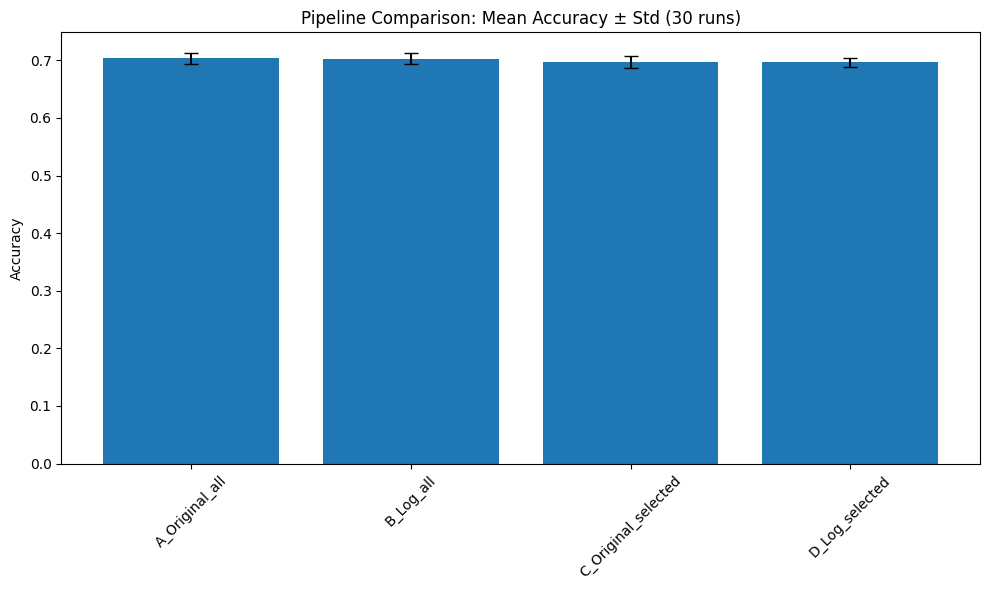


Results saved to 'pipeline_comparison_detailed.xlsx' and 'pipeline_comparison_summary.xlsx'


In [36]:
# ============================================================================
# NEW ABLATION STUDY: Impact of log1p transformation and voting feature selection
# ============================================================================
# This replaces the previous ablation code. It evaluates four pipelines:
# A) Original data (no log) + all features
# B) Log-transformed data + all features
# C) Original data + voting feature selection (selected features)
# D) Log-transformed data + voting feature selection (proposed pipeline)
# ============================================================================

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import RFECV
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import Perceptron
from sklearn.ensemble import GradientBoostingClassifier
import matplotlib.pyplot as plt

def run_pipeline_comparison(df_original, df_log, n_runs=30, cv_folds=10, random_state=42):
    """
    Compare four pipelines using RandomForest classifier.

    Parameters:
    df_original : DataFrame after imputation but WITHOUT log1p transformation
    df_log : DataFrame after log1p transformation (same as df_cleaned_log)
    n_runs : number of repetitions with different random seeds
    cv_folds : number of folds for cross-validation
    random_state : base seed for reproducibility (will be varied)

    Returns:
    results_df : DataFrame with accuracy, precision, recall, F1 for each pipeline and run
    """

    # Target variable
    y = df_original['Selector']  # same for both dataframes
    df_original = df_original.rename(columns={"Sgpt": "SGPT", "Sgot": "SGOT"})
    # ------------------------------------------------------------------
    # 1. Determine selected features using voting feature selection
    #    (run once on the log-transformed data, as in the paper)
    # ------------------------------------------------------------------
    print("Performing voting feature selection on log-transformed data...")
    X_log_all = df_log.drop(columns=['Selector'])

    # Models for voting (same as in original script)
    models = {
        'DecisionTree': DecisionTreeClassifier(random_state=random_state),
        'RandomForest': RandomForestClassifier(random_state=random_state),
        'GradientBoosting': GradientBoostingClassifier(random_state=random_state),
        'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=random_state),
        'LightGBM': LGBMClassifier(random_state=random_state, verbose=-1),
        'Perceptron': Perceptron(max_iter=1000, random_state=random_state)
    }

    # Scale data for Perceptron (but we'll scale inside RFECV for each model)
    from sklearn.preprocessing import MinMaxScaler
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X_log_all)

    # Collect votes
    votes = pd.DataFrame({'Feature': X_log_all.columns})
    for name, model in models.items():
        print(f"  Running RFECV with {name}...")
        if name in ['DecisionTree', 'RandomForest', 'GradientBoosting', 'XGBoost', 'LightGBM']:
            importance_getter = 'feature_importances_'
        else:
            importance_getter = 'coef_'
        rfecv = RFECV(
            estimator=model,
            step=1,
            min_features_to_select=3,
            cv=min(5, cv_folds),
            scoring='accuracy',
            importance_getter=importance_getter,
            n_jobs=-1
        )
        rfecv.fit(X_scaled, y)
        votes[name] = rfecv.support_.astype(int)

    votes['Total'] = votes.iloc[:, 1:].sum(axis=1)
    majority_threshold = len(models) // 2 + 1
    selected_features = votes[votes['Total'] >= majority_threshold]['Feature'].tolist()
    print(f"Selected features by voting: {selected_features}")

    # If no feature reaches majority, take top 3 by votes
    if len(selected_features) == 0:
        selected_features = votes.nlargest(3, 'Total')['Feature'].tolist()
        print(f"  No majority, using top 3: {selected_features}")

    # ------------------------------------------------------------------
    # 2. Define pipelines
    # ------------------------------------------------------------------
    # Pipeline A: original data, all features
    X_A = df_original.drop(columns=['Selector'])

    # Pipeline B: log data, all features
    X_B = df_log.drop(columns=['Selector'])

    # Pipeline C: original data, only selected features
    X_C = df_original[selected_features]

    # Pipeline D: log data, only selected features (proposed)
    X_D = df_log[selected_features]

    pipelines = {
        'A_Original_all': X_A,
        'B_Log_all': X_B,
        'C_Original_selected': X_C,
        'D_Log_selected': X_D
    }

    # ------------------------------------------------------------------
    # 3. Evaluate each pipeline with multiple runs
    # ------------------------------------------------------------------
    all_results = []

    for pipe_name, X in pipelines.items():
        print(f"\nEvaluating pipeline: {pipe_name}")
        for run in range(n_runs):
            seed = random_state + run
            np.random.seed(seed)
            cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=seed)

            # Use RandomForest as the fixed classifier
            clf = RandomForestClassifier(random_state=seed, n_estimators=100)

            # Perform cross-validation and collect scores
            acc_scores = cross_val_score(clf, X, y, cv=cv, scoring='accuracy')
            prec_scores = cross_val_score(clf, X, y, cv=cv, scoring='precision')
            rec_scores = cross_val_score(clf, X, y, cv=cv, scoring='recall')
            f1_scores = cross_val_score(clf, X, y, cv=cv, scoring='f1')

            # Store mean across folds for this run
            all_results.append({
                'pipeline': pipe_name,
                'run': run,
                'accuracy_mean': np.mean(acc_scores),
                'precision_mean': np.mean(prec_scores),
                'recall_mean': np.mean(rec_scores),
                'f1_mean': np.mean(f1_scores)
            })

    # Convert to DataFrame
    results_df = pd.DataFrame(all_results)

    # Compute summary statistics
    summary = results_df.groupby('pipeline').agg({
        'accuracy_mean': ['mean', 'std'],
        'precision_mean': ['mean', 'std'],
        'recall_mean': ['mean', 'std'],
        'f1_mean': ['mean', 'std']
    }).round(4)
    summary.columns = ['acc_mean', 'acc_std', 'prec_mean', 'prec_std', 'rec_mean', 'rec_std', 'f1_mean', 'f1_std']

    print("\n" + "="*60)
    print("PIPELINE COMPARISON RESULTS (30 runs, 10-fold CV)")
    print("="*60)
    print(summary.to_string())

    # Save results
    results_df.to_excel('pipeline_comparison_detailed.xlsx', index=False)
    summary.to_excel('pipeline_comparison_summary.xlsx')

    # Optional: bar plot
    plt.figure(figsize=(10,6))
    plt.bar(summary.index, summary['acc_mean'], yerr=summary['acc_std'], capsize=5)
    plt.ylabel('Accuracy')
    plt.title('Pipeline Comparison: Mean Accuracy ± Std (30 runs)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('pipeline_comparison.png')
    plt.show()

    return results_df, summary

# ------------------------------------------------------------------
# EXECUTION (only if this script is run directly)
# ------------------------------------------------------------------
if __name__ == "__main__":
    # Ensure that df_cleaned (original, after imputation but before log)
    # and df_cleaned_log (after log1p) are available.
    try:
        # These variables come from your original script
        df_original = df_cleaned   # after imputation, no log
        df_log = df_cleaned_log    # after log1p transformation
        print("Dataframes loaded successfully.")
    except NameError:
        print("Error: df_cleaned or df_cleaned_log not found.")
        print("Please run the original preprocessing steps first.")
        exit(1)

    # Run the pipeline comparison
    results, summary = run_pipeline_comparison(df_original, df_log, n_runs=30, cv_folds=10)

    print("\nResults saved to 'pipeline_comparison_detailed.xlsx' and 'pipeline_comparison_summary.xlsx'")

## PIPELINE COMPARISON WITH FIXED FEATURES (Age, DB, Alkphos)

Dataframes loaded successfully.
Available columns in original: ['Age', 'Gender', 'TB', 'DB', 'Alkphos', 'Sgpt', 'Sgot', 'TP', 'ALB', 'AGRatio', 'Selector']

Evaluating pipeline: A_Original_all

Evaluating pipeline: B_Log_all

Evaluating pipeline: C_Original_selected

Evaluating pipeline: D_Log_selected

PIPELINE COMPARISON (30 runs, 10-fold CV) - Fixed features: ['Age', 'DB', 'Alkphos']
                     acc_mean  acc_std  prec_mean  prec_std  rec_mean  rec_std  f1_mean  f1_std
pipeline                                                                                       
A_Original_all         0.7034   0.0092     0.7608    0.0064    0.8537   0.0101   0.8038  0.0063
B_Log_all              0.7030   0.0099     0.7605    0.0070    0.8536   0.0101   0.8035  0.0067
C_Original_selected    0.6886   0.0108     0.7594    0.0077    0.8264   0.0099   0.7904  0.0076
D_Log_selected         0.6900   0.0106     0.7603    0.0080    0.8275   0.0098   0.7914  0.0073


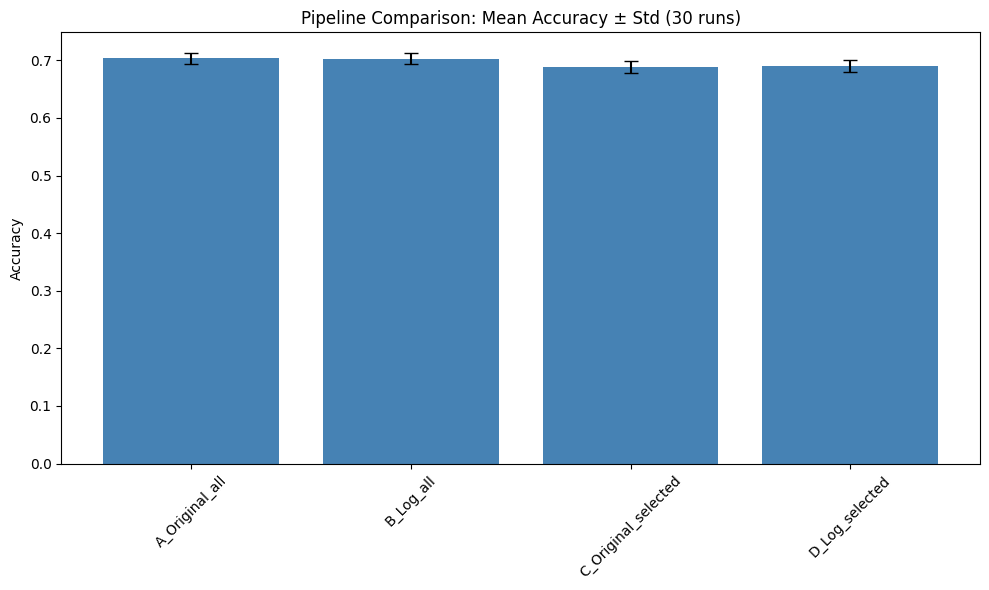


Results saved to 'pipeline_comparison_detailed.xlsx' and 'pipeline_comparison_summary.xlsx'


In [37]:
# ============================================================================
# PIPELINE COMPARISON WITH FIXED FEATURES (Age, DB, Alkphos)
# ============================================================================
# This compares four pipelines using RandomForest:
# A) Original data, all features
# B) Log-transformed data, all features
# C) Original data, only fixed selected features (Age, DB, Alkphos)
# D) Log-transformed data, only fixed selected features (proposed)
# ============================================================================

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
import matplotlib.pyplot as plt

def run_fixed_features_comparison(df_original, df_log, fixed_features, n_runs=30, cv_folds=10, random_state=42):
    """
    Compare four pipelines using RandomForest classifier.

    Parameters:
    df_original : DataFrame with original scale (no log1p)
    df_log : DataFrame with log1p transformation
    fixed_features : list of feature names to use as selected set (e.g., ['Age', 'DB', 'Alkphos'])
    n_runs : number of repetitions with different seeds
    cv_folds : number of folds for cross-validation
    """

    y = df_original['Selector']

    # Ensure fixed features exist in both dataframes
    missing_orig = [f for f in fixed_features if f not in df_original.columns]
    missing_log = [f for f in fixed_features if f not in df_log.columns]
    if missing_orig or missing_log:
        raise KeyError(f"Missing features in original: {missing_orig}, in log: {missing_log}")

    # Define pipelines
    pipelines = {
        'A_Original_all': df_original.drop(columns=['Selector']),
        'B_Log_all': df_log.drop(columns=['Selector']),
        'C_Original_selected': df_original[fixed_features],
        'D_Log_selected': df_log[fixed_features]
    }

    all_results = []

    for pipe_name, X in pipelines.items():
        print(f"\nEvaluating pipeline: {pipe_name}")
        for run in range(n_runs):
            seed = random_state + run
            np.random.seed(seed)
            cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=seed)
            clf = RandomForestClassifier(random_state=seed, n_estimators=100)

            acc_scores = cross_val_score(clf, X, y, cv=cv, scoring='accuracy')
            prec_scores = cross_val_score(clf, X, y, cv=cv, scoring='precision')
            rec_scores = cross_val_score(clf, X, y, cv=cv, scoring='recall')
            f1_scores = cross_val_score(clf, X, y, cv=cv, scoring='f1')

            all_results.append({
                'pipeline': pipe_name,
                'run': run,
                'accuracy_mean': np.mean(acc_scores),
                'precision_mean': np.mean(prec_scores),
                'recall_mean': np.mean(rec_scores),
                'f1_mean': np.mean(f1_scores)
            })

    results_df = pd.DataFrame(all_results)

    # Summary table
    summary = results_df.groupby('pipeline').agg({
        'accuracy_mean': ['mean', 'std'],
        'precision_mean': ['mean', 'std'],
        'recall_mean': ['mean', 'std'],
        'f1_mean': ['mean', 'std']
    }).round(4)
    summary.columns = ['acc_mean', 'acc_std', 'prec_mean', 'prec_std', 'rec_mean', 'rec_std', 'f1_mean', 'f1_std']

    print("\n" + "="*60)
    print("PIPELINE COMPARISON (30 runs, 10-fold CV) - Fixed features: {}".format(fixed_features))
    print("="*60)
    print(summary.to_string())

    # Save to Excel
    results_df.to_excel('pipeline_comparison_detailed.xlsx', index=False)
    summary.to_excel('pipeline_comparison_summary.xlsx')

    # Bar plot
    plt.figure(figsize=(10,6))
    plt.bar(summary.index, summary['acc_mean'], yerr=summary['acc_std'], capsize=5, color='steelblue')
    plt.ylabel('Accuracy')
    plt.title('Pipeline Comparison: Mean Accuracy ± Std (30 runs)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('pipeline_comparison.png')
    plt.show()

    return results_df, summary

# ============================================================================
# EXECUTION
# ============================================================================
if __name__ == "__main__":
    # Ensure dataframes exist from original script
    try:
        df_original = df_cleaned.copy()   # original imputed (no log)
        df_log = df_cleaned_log.copy()    # after log1p
        print("Dataframes loaded successfully.")
    except NameError:
        print("Error: df_cleaned or df_cleaned_log not found.")
        print("Please run the original preprocessing steps first.")
        exit(1)

    print("Available columns in original:", df_original.columns.tolist())

    # Fixed features as per the paper's voting results
    FIXED_FEATURES = ['Age', 'DB', 'Alkphos']

    # Run comparison
    results, summary = run_fixed_features_comparison(
        df_original, df_log,
        fixed_features=FIXED_FEATURES,
        n_runs=30,
        cv_folds=10
    )

    print("\nResults saved to 'pipeline_comparison_detailed.xlsx' and 'pipeline_comparison_summary.xlsx'")

In [40]:
# ============================================================================
# AVALIAÇÃO DOS MESMOS MODELOS DO RFECV COM MINMAXSCALER (ESTILO ORIGINAL)
# ============================================================================
# - Features fixas: ['Age', 'DB', 'Alkphos']
# - Pipelines:
#   A: dados originais, todas features
#   B: dados log, todas features
#   C: dados originais, apenas features selecionadas
#   D: dados log, apenas features selecionadas (proposto)
# - Modelos: DecisionTree, RandomForest, GradientBoosting, XGBoost, LightGBM, Perceptron
# - Escala: MinMaxScaler aplicado UMA VEZ sobre todo o X de cada pipeline (como no RFECV)
# - 30 runs de 10-fold CV (shuffle diferente a cada run)
# - Salva acurácia média por run, gera tabela resumo e gráficos
# ============================================================================

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Modelos (exatamente os mesmos do RFECV)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import Perceptron

def run_models_like_rfecv(df_original, df_log, fixed_features, n_runs=30, cv_folds=10, random_state=42):
    """
    Avalia os 6 modelos usando a mesma abordagem de escala do RFECV original.
    """
    y = df_original['Selector']

    # Verifica features
    for f in fixed_features:
        if f not in df_original.columns or f not in df_log.columns:
            raise KeyError(f"Feature {f} não encontrada")

    # Definição das pipelines
    pipelines = {
        'A_Original_all': df_original.drop(columns=['Selector']),
        'B_Log_all': df_log.drop(columns=['Selector']),
        'C_Original_selected': df_original[fixed_features],
        'D_Log_selected': df_log[fixed_features]
    }

    # Modelos (com random_state inicial, será redefinido a cada run)
    base_models = {
        'DecisionTree': DecisionTreeClassifier,
        'RandomForest': RandomForestClassifier,
        'GradientBoosting': GradientBoostingClassifier,
        'XGBoost': XGBClassifier,
        'LightGBM': LGBMClassifier,
        'Perceptron': Perceptron
    }

    # Parâmetros específicos de cada modelo
    model_params = {
        'DecisionTree': {},
        'RandomForest': {'n_estimators': 100},
        'GradientBoosting': {},
        'XGBoost': {'use_label_encoder': False, 'eval_metric': 'logloss'},
        'LightGBM': {'verbose': -1},
        'Perceptron': {'max_iter': 1000}
    }

    records = []
    print("Iniciando avaliação (30 runs, 10-fold CV) com MinMaxScaler (estilo RFECV)...")

    for model_name, model_class in base_models.items():
        print(f"\n--- Modelo: {model_name} ---")
        for pipe_name, X in pipelines.items():
            print(f"  Pipeline: {pipe_name}")

            # Escala os dados UMA VEZ (como no RFECV original)
            scaler = MinMaxScaler()
            X_scaled = scaler.fit_transform(X)

            for run in range(n_runs):
                seed = random_state + run
                np.random.seed(seed)
                cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=seed)

                # Cria o modelo com o seed atual
                params = model_params[model_name].copy()
                params['random_state'] = seed
                model = model_class(**params)

                # Cross-validation sobre os dados já escalados
                acc_scores = cross_val_score(model, X_scaled, y, cv=cv, scoring='accuracy')
                mean_acc = np.mean(acc_scores)

                records.append({
                    'modelo': model_name,
                    'pipeline': pipe_name,
                    'run': run,
                    'accuracy': mean_acc
                })

    df_results = pd.DataFrame(records)

    # Tabela resumo
    summary = df_results.groupby(['modelo', 'pipeline'])['accuracy'].agg(['mean', 'std']).round(4)
    summary.columns = ['mean_acc', 'std_acc']
    print("\n" + "="*80)
    print("RESUMO (30 runs, 10-fold CV) - Média ± Desvio Padrão da Acurácia")
    print("Escala: MinMaxScaler aplicado globalmente (como no RFECV original)")
    print("="*80)
    print(summary)

    # Salvar resultados
    df_results.to_excel('todos_modelos_estilo_rfecv_resultados_detalhados.xlsx', index=False)
    summary.to_excel('todos_modelos_estilo_rfecv_sumario.xlsx')

    # Gráficos de barras para cada modelo
    plot_data = summary.reset_index()
    modelos_unicos = plot_data['modelo'].unique()
    for modelo in modelos_unicos:
        subset = plot_data[plot_data['modelo'] == modelo]
        pipelines_ordem = ['A_Original_all', 'B_Log_all', 'C_Original_selected', 'D_Log_selected']
        subset = subset.set_index('pipeline').reindex(pipelines_ordem).dropna()
        plt.figure(figsize=(8,5))
        bars = plt.bar(subset.index, subset['mean_acc'], yerr=subset['std_acc'], capsize=5,
                       color=['#1f77b4','#ff7f0e','#2ca02c','#d62728'])
        plt.ylabel('Acurácia')
        plt.title(f'Comparação de pipelines (estilo RFECV) - {modelo}')
        plt.ylim(0, 1)
        plt.grid(axis='y', alpha=0.3)
        for bar, acc in zip(bars, subset['mean_acc']):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{acc:.3f}', ha='center', fontsize=9)
        plt.tight_layout()
        plt.savefig(f'comparacao_estilo_rfecv_{modelo}.png')
        plt.close()
        print(f"Gráfico salvo: comparacao_estilo_rfecv_{modelo}.png")

    return df_results, summary

# ============================================================================
# EXECUÇÃO
# ============================================================================
if __name__ == "__main__":
    try:
        df_original = df_cleaned.copy()
        df_log = df_cleaned_log.copy()
        print("Dataframes carregados com sucesso.")
    except NameError:
        print("Erro: df_cleaned ou df_cleaned_log não encontrados.")
        print("Execute o pré-processamento original primeiro.")
        exit(1)



    print("Colunas disponíveis no df_original:", df_original.columns.tolist())
    FIXED_FEATURES = ['Age', 'DB', 'Alkphos']

    df_detalhado, tabela = run_models_like_rfecv(
        df_original, df_log,
        fixed_features=FIXED_FEATURES,
        n_runs=30,
        cv_folds=10
    )

    print("\nArquivos gerados:")
    print(" - todos_modelos_estilo_rfecv_resultados_detalhados.xlsx")
    print(" - todos_modelos_estilo_rfecv_sumario.xlsx")
    print(" - comparacao_estilo_rfecv_*.png")

Dataframes carregados com sucesso.
Colunas disponíveis no df_original: ['Age', 'Gender', 'TB', 'DB', 'Alkphos', 'Sgpt', 'Sgot', 'TP', 'ALB', 'AGRatio', 'Selector']
Iniciando avaliação (30 runs, 10-fold CV) com MinMaxScaler (estilo RFECV)...

--- Modelo: DecisionTree ---
  Pipeline: A_Original_all
  Pipeline: B_Log_all
  Pipeline: C_Original_selected
  Pipeline: D_Log_selected

--- Modelo: RandomForest ---
  Pipeline: A_Original_all
  Pipeline: B_Log_all
  Pipeline: C_Original_selected
  Pipeline: D_Log_selected

--- Modelo: GradientBoosting ---
  Pipeline: A_Original_all
  Pipeline: B_Log_all
  Pipeline: C_Original_selected
  Pipeline: D_Log_selected

--- Modelo: XGBoost ---
  Pipeline: A_Original_all
  Pipeline: B_Log_all
  Pipeline: C_Original_selected
  Pipeline: D_Log_selected

--- Modelo: LightGBM ---
  Pipeline: A_Original_all
  Pipeline: B_Log_all
  Pipeline: C_Original_selected
  Pipeline: D_Log_selected

--- Modelo: Perceptron ---
  Pipeline: A_Original_all
  Pipeline: B_Log_a

In [35]:
# ============================================================================
# COMPARAÇÃO CORRETA COM MINMAXSCALER DENTRO DA VALIDAÇÃO CRUZADA (Pipeline)
# ============================================================================
# - Features fixas: ['Age', 'DB', 'Alkphos']
# - Pipelines:
#   A: dados originais, todas features
#   B: dados log, todas features
#   C: dados originais, apenas features selecionadas
#   D: dados log, apenas features selecionadas (proposto)
# - Modelos: DecisionTree, RandomForest, GradientBoosting, XGBoost, LightGBM, Perceptron
# - Escala: MinMaxScaler ajustado APENAS nos dados de treino de cada fold (via Pipeline)
# - 30 runs de 10-fold CV, salva acurácia por run
# - Gera tabela resumo e gráficos (sem testes estatísticos)
# ============================================================================

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Modelos
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import Perceptron

def run_correct_scaling_comparison(df_original, df_log, fixed_features, n_runs=30, cv_folds=10, random_state=42):
    """
    Avalia os 6 modelos com MinMaxScaler aplicado corretamente dentro de cada fold.
    """
    y = df_original['Selector']

    # Verifica features
    for f in fixed_features:
        if f not in df_original.columns or f not in df_log.columns:
            raise KeyError(f"Feature {f} não encontrada")

    pipelines = {
        'A_Original_all': df_original.drop(columns=['Selector']),
        'B_Log_all': df_log.drop(columns=['Selector']),
        'C_Original_selected': df_original[fixed_features],
        'D_Log_selected': df_log[fixed_features]
    }

    # Modelos base (serão envolvidos em pipeline com scaler)
    base_models = {
        'DecisionTree': DecisionTreeClassifier,
        'RandomForest': RandomForestClassifier,
        'GradientBoosting': GradientBoostingClassifier,
        'XGBoost': XGBClassifier,
        'LightGBM': LGBMClassifier,
        'Perceptron': Perceptron
    }

    # Parâmetros padrão (sem random_state agora, pois será definido a cada run)
    model_params = {
        'DecisionTree': {},
        'RandomForest': {'n_estimators': 100},
        'GradientBoosting': {},
        'XGBoost': {'use_label_encoder': False, 'eval_metric': 'logloss'},
        'LightGBM': {'verbose': -1},
        'Perceptron': {'max_iter': 1000}
    }

    records = []
    print("Iniciando avaliação COM ESCALONAMENTO CORRETO (Pipeline dentro do CV) - 30 runs, 10-fold CV")

    for model_name, model_class in base_models.items():
        print(f"\n--- Modelo: {model_name} ---")
        for pipe_name, X in pipelines.items():
            print(f"  Pipeline: {pipe_name}")
            for run in range(n_runs):
                seed = random_state + run
                np.random.seed(seed)
                cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=seed)

                # Cria o modelo com o seed atual
                params = model_params[model_name].copy()
                params['random_state'] = seed
                model = model_class(**params)

                # Cria pipeline com MinMaxScaler + modelo
                pipeline = make_pipeline(MinMaxScaler(), model)

                # Cross-validation (o scaler é ajustado apenas nos dados de treino de cada fold)
                acc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')
                mean_acc = np.mean(acc_scores)

                records.append({
                    'modelo': model_name,
                    'pipeline': pipe_name,
                    'run': run,
                    'accuracy': mean_acc
                })

    df_results = pd.DataFrame(records)

    # Tabela resumo
    summary = df_results.groupby(['modelo', 'pipeline'])['accuracy'].agg(['mean', 'std']).round(4)
    summary.columns = ['mean_acc', 'std_acc']
    print("\n" + "="*80)
    print("RESUMO (30 runs, 10-fold CV) - Média ± Desvio Padrão da Acurácia")
    print("Escala: MinMaxScaler aplicado corretamente dentro de cada fold (via Pipeline)")
    print("="*80)
    print(summary)

    # Salvar resultados
    df_results.to_excel('todos_modelos_escala_correta_resultados_detalhados.xlsx', index=False)
    summary.to_excel('todos_modelos_escala_correta_sumario.xlsx')

    # Gráficos de barras
    plot_data = summary.reset_index()
    modelos_unicos = plot_data['modelo'].unique()
    for modelo in modelos_unicos:
        subset = plot_data[plot_data['modelo'] == modelo]
        pipelines_ordem = ['A_Original_all', 'B_Log_all', 'C_Original_selected', 'D_Log_selected']
        subset = subset.set_index('pipeline').reindex(pipelines_ordem).dropna()
        plt.figure(figsize=(8,5))
        bars = plt.bar(subset.index, subset['mean_acc'], yerr=subset['std_acc'], capsize=5,
                       color=['#1f77b4','#ff7f0e','#2ca02c','#d62728'])
        plt.ylabel('Acurácia')
        plt.title(f'Comparação de pipelines (escala correta) - {modelo}')
        plt.ylim(0, 1)
        plt.grid(axis='y', alpha=0.3)
        for bar, acc in zip(bars, subset['mean_acc']):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{acc:.3f}', ha='center', fontsize=9)
        plt.tight_layout()
        plt.savefig(f'comparacao_escala_correta_{modelo}.png')
        plt.close()
        print(f"Gráfico salvo: comparacao_escala_correta_{modelo}.png")

    return df_results, summary

# ============================================================================
# EXECUÇÃO
# ============================================================================
if __name__ == "__main__":
    try:
        df_original = df_cleaned.copy()
        df_log = df_cleaned_log.copy()
        print("Dataframes carregados com sucesso.")
    except NameError:
        print("Erro: df_cleaned ou df_cleaned_log não encontrados.")
        print("Execute o pré-processamento original primeiro.")
        exit(1)

    # Renomeação não necessária para Age, DB, Alkphos
    print("Colunas disponíveis no df_original:", df_original.columns.tolist())
    FIXED_FEATURES = ['Age', 'DB', 'Alkphos']

    df_detalhado, tabela = run_correct_scaling_comparison(
        df_original, df_log,
        fixed_features=FIXED_FEATURES,
        n_runs=30,
        cv_folds=10
    )

    print("\nArquivos gerados (escala correta):")
    print(" - todos_modelos_escala_correta_resultados_detalhados.xlsx")
    print(" - todos_modelos_escala_correta_sumario.xlsx")
    print(" - comparacao_escala_correta_*.png")

Dataframes carregados com sucesso.
Colunas disponíveis no df_original: ['Age', 'Gender', 'TB', 'DB', 'Alkphos', 'Sgpt', 'Sgot', 'TP', 'ALB', 'AGRatio', 'Selector']
Iniciando avaliação COM ESCALONAMENTO CORRETO (Pipeline dentro do CV) - 30 runs, 10-fold CV

--- Modelo: DecisionTree ---
  Pipeline: A_Original_all
  Pipeline: B_Log_all
  Pipeline: C_Original_selected
  Pipeline: D_Log_selected

--- Modelo: RandomForest ---
  Pipeline: A_Original_all
  Pipeline: B_Log_all
  Pipeline: C_Original_selected
  Pipeline: D_Log_selected

--- Modelo: GradientBoosting ---
  Pipeline: A_Original_all
  Pipeline: B_Log_all
  Pipeline: C_Original_selected
  Pipeline: D_Log_selected

--- Modelo: XGBoost ---
  Pipeline: A_Original_all
  Pipeline: B_Log_all
  Pipeline: C_Original_selected
  Pipeline: D_Log_selected

--- Modelo: LightGBM ---
  Pipeline: A_Original_all
  Pipeline: B_Log_all
  Pipeline: C_Original_selected
  Pipeline: D_Log_selected

--- Modelo: Perceptron ---
  Pipeline: A_Original_all
  Pi

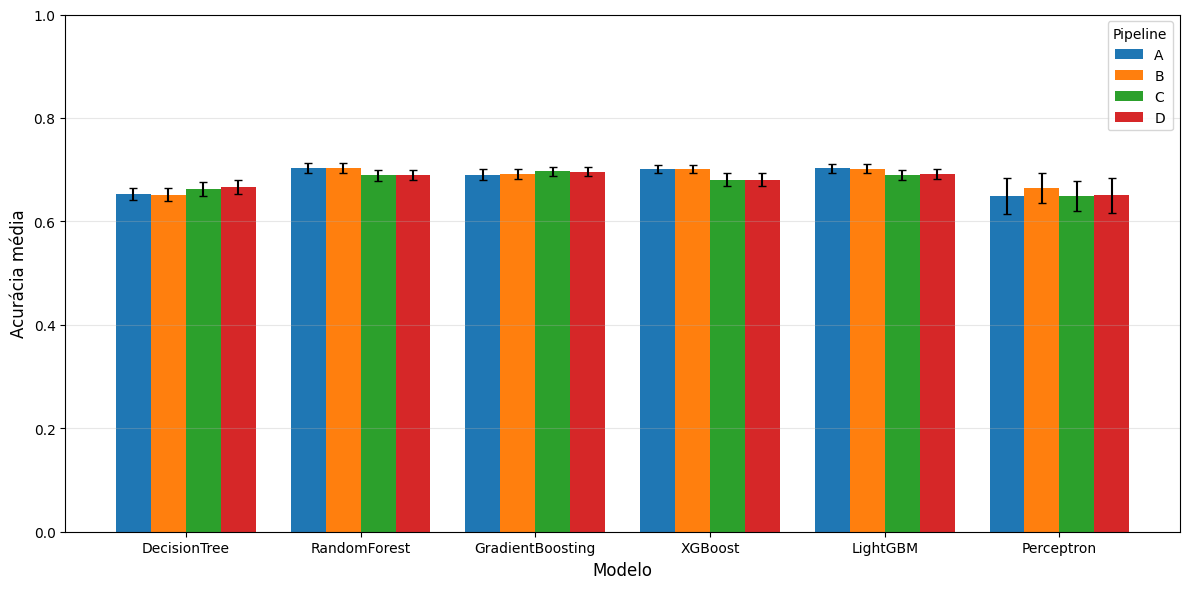

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Carregar o sumário gerado pelo treinamento
summary = pd.read_excel('todos_modelos_escala_correta_sumario.xlsx', index_col=[0, 1])
summary = summary.reset_index()

# Renomear pipelines para nomes mais curtos (opcional)
pipeline_names = {
    'A_Original_all': 'A',
    'B_Log_all': 'B',
    'C_Original_selected': 'C',
    'D_Log_selected': 'D'
}
summary['pipeline'] = summary['pipeline'].map(pipeline_names)

# Definir ordem dos modelos e pipelines
model_order = ['DecisionTree', 'RandomForest', 'GradientBoosting', 'XGBoost', 'LightGBM', 'Perceptron']
pipeline_order = ['A', 'B', 'C', 'D']

# Preparar dados para plotagem
x = np.arange(len(model_order))
width = 0.2  # largura de cada barra
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

fig, ax = plt.subplots(figsize=(12, 6))

for i, (pipe, color) in enumerate(zip(pipeline_order, colors)):
    subset = summary[summary['pipeline'] == pipe]
    means = [subset[subset['modelo'] == m]['mean_acc'].values[0] for m in model_order]
    stds = [subset[subset['modelo'] == m]['std_acc'].values[0] for m in model_order]
    ax.bar(x + i*width, means, width, label=pipe, color=color, yerr=stds, capsize=3)

ax.set_xlabel('Modelo', fontsize=12)
ax.set_ylabel('Acurácia média', fontsize=12)
#ax.set_title('Comparação de pipelines para todos os modelos (escala correta)', fontsize=14)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(model_order, rotation=0, ha='center')
ax.legend(title='Pipeline')
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('comparacao_todos_modelos.png', dpi=300)
plt.show()

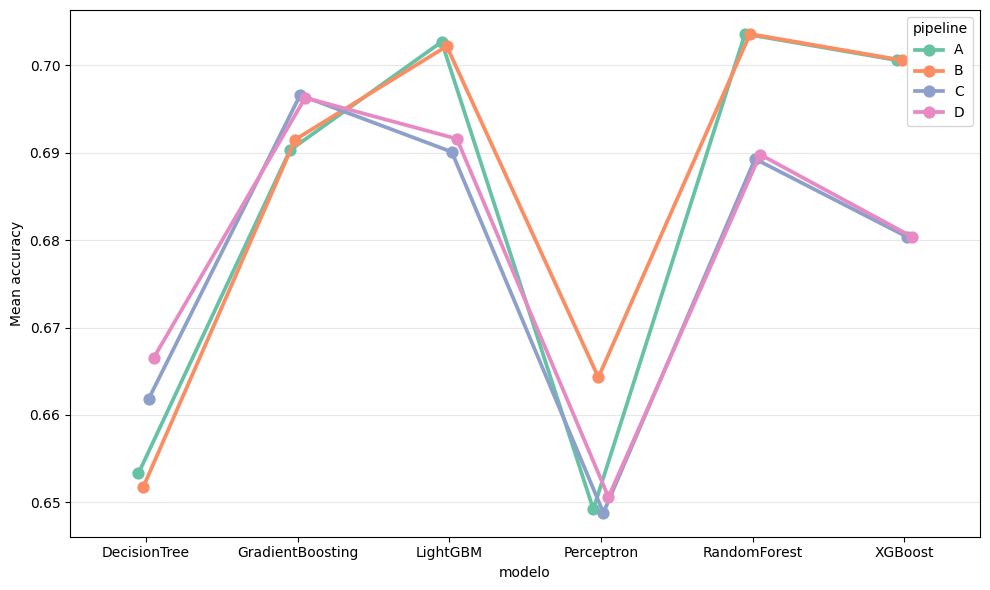

In [43]:
import seaborn as sns

summary = pd.read_excel('todos_modelos_escala_correta_sumario.xlsx', index_col=[0, 1]).reset_index()
summary['pipeline'] = summary['pipeline'].map({
    'A_Original_all': 'A',
    'B_Log_all': 'B',
    'C_Original_selected': 'C',
    'D_Log_selected': 'D'
})

plt.figure(figsize=(10, 6))
sns.pointplot(data=summary, x='modelo', y='mean_acc', hue='pipeline',
              dodge=True, capsize=0.2, errwidth=1.5, palette='Set2')
plt.xticks(rotation=0, ha='center')
plt.ylabel('Mean accuracy')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('comparacao_todos_modelos_points.png', dpi=300)
plt.show()

## Deep learning

Carregando dados...
Usando df_cleaned_log (log-transformado)
Treino: (466, 10), Teste: (117, 10)
Distribuição target - Treino: [133 333] | Teste: [34 83]

=== TREINANDO MLP (validação cruzada) ===
Early stopping no epoch 30
Early stopping no epoch 49
Early stopping no epoch 14
Early stopping no epoch 23
Early stopping no epoch 29
MLP - Acurácia: 0.6946 | Precisão: 0.7631 | Recall: 0.8292 | F1: 0.7931

=== TREINANDO TABNET (validação cruzada) ===

Early stopping occurred at epoch 40 with best_epoch = 20 and best_val_0_auc = 0.80628

Early stopping occurred at epoch 28 with best_epoch = 8 and best_val_0_auc = 0.78313

Early stopping occurred at epoch 25 with best_epoch = 5 and best_val_0_auc = 0.73459

Early stopping occurred at epoch 34 with best_epoch = 14 and best_val_0_auc = 0.74772

Early stopping occurred at epoch 37 with best_epoch = 17 and best_val_0_auc = 0.78861
TabNet - Acurácia: 0.7307 | Precisão: 0.7490 | Recall: 0.9425 | F1: 0.8332

=== TREINANDO RANDOM FOREST (validação cr

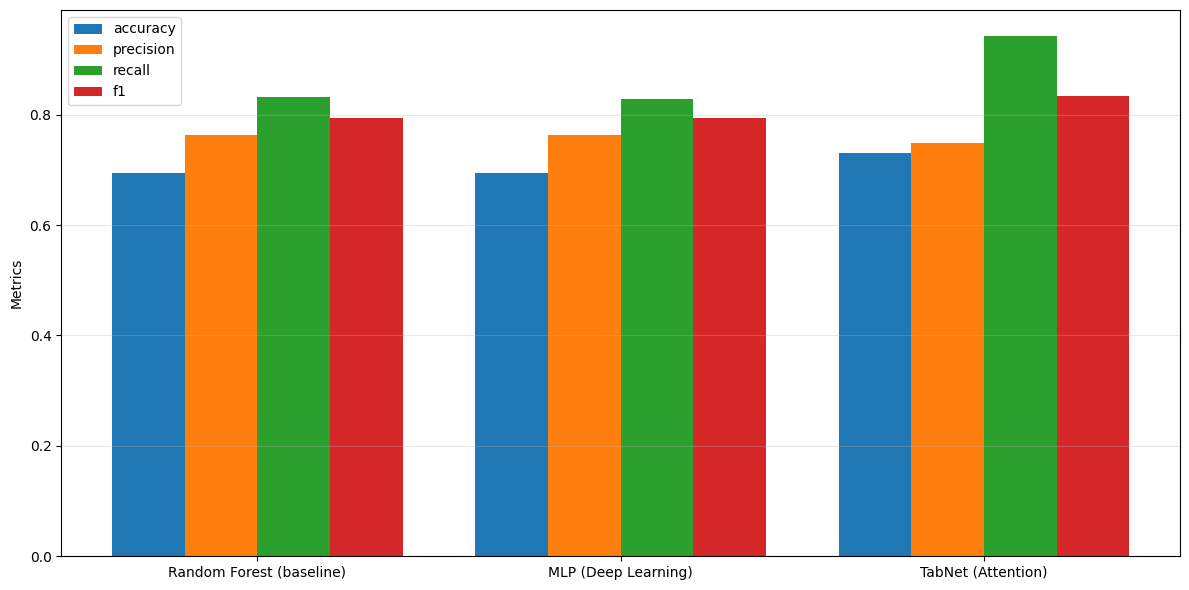


Arquivos gerados: deep_learning_results.xlsx, deep_learning_comparison.png

Nota: Os resultados de Deep Learning (MLP/TabNet) são apenas experimentais e não substituem o método proposto no artigo.


In [48]:
# ============================================================================
# DEEP LEARNING PARA CLASSIFICAÇÃO DE DOENÇA HEPÁTICA (EXPERIMENTO COMPLEMENTAR)
# ============================================================================
# Modelos:
#   1. MLP (Multi-Layer Perceptron) com Dropout e Batch Normalization
#   2. TabNet (attention-based para dados tabulares)
#   3. RandomForest (baseline)
# ============================================================================

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# Deep learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# TabNet (instalar: pip install pytorch-tabnet)
from pytorch_tabnet.tab_model import TabNetClassifier

# ============================================================================
# 1. PREPARAÇÃO DOS DADOS
# ============================================================================
# Usar df_cleaned_log (após log1p) ou df_cleaned (original)
# Para deep learning, recomendamos padronizar (StandardScaler) em vez de MinMax.
print("Carregando dados...")
try:
    df = df_cleaned_log.copy()   # ou df_cleaned
    print("Usando df_cleaned_log (log-transformado)")
except NameError:
    try:
        df = df_cleaned.copy()
        print("Usando df_cleaned (original)")
    except NameError:
        raise NameError("Nenhum dataframe encontrado. Execute o pré-processamento primeiro.")

# Separar features e target
X = df.drop(columns=['Selector'])
y = df['Selector'].values

# Codificar variáveis categóricas (Gender)
if 'Gender' in X.columns:
    X = pd.get_dummies(X, columns=['Gender'], drop_first=True)

# Dividir em treino (80%) e teste (20%) para avaliação final
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Padronizar (StandardScaler) – necessário para MLP e TabNet
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Treino: {X_train_scaled.shape}, Teste: {X_test_scaled.shape}")
print(f"Distribuição target - Treino: {np.bincount(y_train)} | Teste: {np.bincount(y_test)}")

# ============================================================================
# 2. MODELO MLP (PyTorch)
# ============================================================================
class MLPClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dims=[128, 64], dropout=0.3):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, h_dim))
            layers.append(nn.BatchNorm1d(h_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_dim = h_dim
        layers.append(nn.Linear(prev_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze()

def train_mlp(X_train, y_train, X_val, y_val, epochs=100, batch_size=32, lr=0.001, patience=10):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = MLPClassifier(input_dim=X_train.shape[1]).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                                  torch.tensor(y_train, dtype=torch.float32))
    val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.float32),
                                torch.tensor(y_val, dtype=torch.float32))
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)

    best_loss = np.inf
    patience_counter = 0
    for epoch in range(epochs):
        model.train()
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            pred = model(batch_x)
            loss = criterion(pred, batch_y)
            loss.backward()
            optimizer.step()

        # Validação
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                pred = model(batch_x)
                loss = criterion(pred, batch_y)
                val_loss += loss.item()
        val_loss /= len(val_loader)

        if val_loss < best_loss:
            best_loss = val_loss
            patience_counter = 0
            best_model_state = model.state_dict()
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping no epoch {epoch+1}")
                break

    model.load_state_dict(best_model_state)
    return model

# Avaliar MLP com validação cruzada (para consistência)
def evaluate_mlp_cv(X, y, cv_folds=5):
    skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    acc_list, prec_list, rec_list, f1_list = [], [], [], []
    for train_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]
        model = train_mlp(X_tr, y_tr, X_val, y_val, epochs=100)
        model.eval()
        with torch.no_grad():
            logits = model(torch.tensor(X_val, dtype=torch.float32))
            preds = (torch.sigmoid(logits) > 0.5).cpu().numpy()
        acc = accuracy_score(y_val, preds)
        prec = precision_score(y_val, preds)
        rec = recall_score(y_val, preds)
        f1 = f1_score(y_val, preds)
        acc_list.append(acc); prec_list.append(prec); rec_list.append(rec); f1_list.append(f1)
    return np.mean(acc_list), np.mean(prec_list), np.mean(rec_list), np.mean(f1_list)

print("\n=== TREINANDO MLP (validação cruzada) ===")
# Usar X_scaled completo (já padronizado) para CV
X_full_scaled = scaler.fit_transform(X)  # reescalona todo o X para CV
acc_mlp, prec_mlp, rec_mlp, f1_mlp = evaluate_mlp_cv(X_full_scaled, y, cv_folds=5)
print(f"MLP - Acurácia: {acc_mlp:.4f} | Precisão: {prec_mlp:.4f} | Recall: {rec_mlp:.4f} | F1: {f1_mlp:.4f}")

# ============================================================================
# 3. TABNET
# ============================================================================
def evaluate_tabnet_cv(X, y, cv_folds=5):
    skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    acc_list, prec_list, rec_list, f1_list = [], [], [], []
    for train_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]
        clf = TabNetClassifier(verbose=0, seed=42, device_name='cpu')
        clf.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], patience=20, max_epochs=100, batch_size=32)
        preds = clf.predict(X_val)
        acc = accuracy_score(y_val, preds)
        prec = precision_score(y_val, preds)
        rec = recall_score(y_val, preds)
        f1 = f1_score(y_val, preds)
        acc_list.append(acc); prec_list.append(prec); rec_list.append(rec); f1_list.append(f1)
    return np.mean(acc_list), np.mean(prec_list), np.mean(rec_list), np.mean(f1_list)

print("\n=== TREINANDO TABNET (validação cruzada) ===")
try:
    acc_tab, prec_tab, rec_tab, f1_tab = evaluate_tabnet_cv(X_full_scaled, y, cv_folds=5)
    print(f"TabNet - Acurácia: {acc_tab:.4f} | Precisão: {prec_tab:.4f} | Recall: {rec_tab:.4f} | F1: {f1_tab:.4f}")
except Exception as e:
    print(f"TabNet não pôde ser executado: {e}")
    acc_tab = prec_tab = rec_tab = f1_tab = 0.0

# ============================================================================
# 4. BASELINE: RANDOM FOREST
# ============================================================================
print("\n=== TREINANDO RANDOM FOREST (validação cruzada) ===")
rf = RandomForestClassifier(n_estimators=100, random_state=42)
acc_rf = cross_val_score(rf, X_full_scaled, y, cv=5, scoring='accuracy').mean()
prec_rf = cross_val_score(rf, X_full_scaled, y, cv=5, scoring='precision').mean()
rec_rf = cross_val_score(rf, X_full_scaled, y, cv=5, scoring='recall').mean()
f1_rf = cross_val_score(rf, X_full_scaled, y, cv=5, scoring='f1').mean()
print(f"Random Forest - Acurácia: {acc_rf:.4f} | Precisão: {prec_rf:.4f} | Recall: {rec_rf:.4f} | F1: {f1_rf:.4f}")

# ============================================================================
# 5. COMPARAÇÃO E GRÁFICO
# ============================================================================
results = pd.DataFrame({
    'Modelo': ['Random Forest (baseline)', 'MLP (Deep Learning)', 'TabNet (Attention)'],
    'accuracy': [acc_rf, acc_mlp, acc_tab],
    'precision': [prec_rf, prec_mlp, prec_tab],
    'recall': [rec_rf, rec_mlp, rec_tab],
    'f1': [f1_rf, f1_mlp, f1_tab]
})
print("\n=== RESULTADOS FINAIS (5-fold CV) ===")
print(results.to_string(index=False))

# Salvar resultados
results.to_excel('deep_learning_results.xlsx', index=False)

# Gráfico de barras comparativo
metrics = ['accuracy', 'precision', 'recall', 'f1']
x = np.arange(len(results['Modelo']))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))
for i, metric in enumerate(metrics):
    ax.bar(x + i*width, results[metric], width, label=metric)
ax.set_ylabel('Metrics')
#ax.set_title('Comparação entre Deep Learning e Baseline')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results['Modelo'], rotation=0, ha='center')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('deep_learning_comparison.png', dpi=300)
plt.show()

print("\nArquivos gerados: deep_learning_results.xlsx, deep_learning_comparison.png")
print("\nNota: Os resultados de Deep Learning (MLP/TabNet) são apenas experimentais e não substituem o método proposto no artigo.")

## Wilcoxon test

Dataframes carregados com sucesso.
Colunas disponíveis no df_original: ['Age', 'Gender', 'TB', 'DB', 'Alkphos', 'Sgpt', 'Sgot', 'TP', 'ALB', 'AGRatio', 'Selector']
Iniciando avaliação (30 runs, 10-fold CV) com escala correta...

--- Modelo: DecisionTree ---
  Pipeline: A_Original_all
  Pipeline: B_Log_all
  Pipeline: C_Original_selected
  Pipeline: D_Log_selected

--- Modelo: RandomForest ---
  Pipeline: A_Original_all
  Pipeline: B_Log_all
  Pipeline: C_Original_selected
  Pipeline: D_Log_selected

--- Modelo: GradientBoosting ---
  Pipeline: A_Original_all
  Pipeline: B_Log_all
  Pipeline: C_Original_selected
  Pipeline: D_Log_selected

--- Modelo: XGBoost ---
  Pipeline: A_Original_all
  Pipeline: B_Log_all
  Pipeline: C_Original_selected
  Pipeline: D_Log_selected

--- Modelo: LightGBM ---
  Pipeline: A_Original_all
  Pipeline: B_Log_all
  Pipeline: C_Original_selected
  Pipeline: D_Log_selected

--- Modelo: Perceptron ---
  Pipeline: A_Original_all
  Pipeline: B_Log_all
  Pipeline

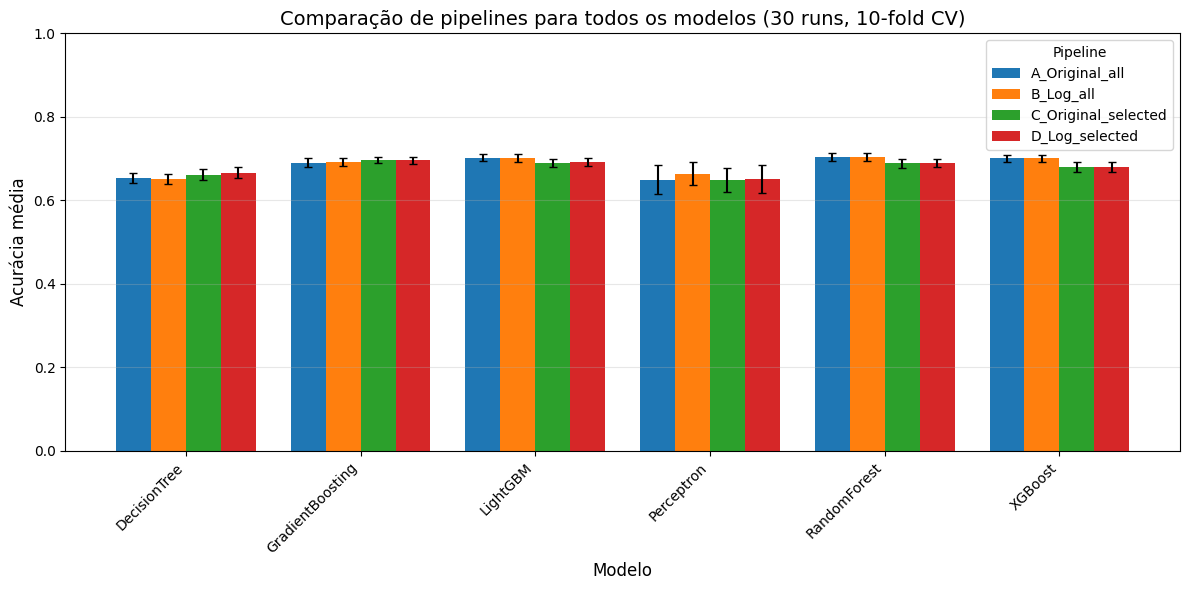


Arquivos gerados:
 - resultados_detalhados_wilcoxon.xlsx (acurácia por run/modelo/pipeline)
 - sumario_wilcoxon.xlsx (média ± desvio padrão)
 - wilcoxon_pvalues.xlsx (p‑valores das comparações D vs outros)
 - comparacao_todos_modelos_wilcoxon.png (gráfico de barras agrupadas)


In [49]:
# ============================================================================
# AVALIAÇÃO DOS 6 MODELOS NAS 4 PIPELINES COM WILCOXON (ESCALA CORRETA)
# ============================================================================
# - Modelos: DecisionTree, RandomForest, GradientBoosting, XGBoost, LightGBM, Perceptron
# - Pipelines: A_Original_all, B_Log_all, C_Original_selected, D_Log_selected (proposta)
# - Features selecionadas: ['Age', 'DB', 'Alkphos']
# - Escala: MinMaxScaler aplicado DENTRO de cada fold via Pipeline
# - 30 runs de 10‑fold CV (shuffle diferente a cada run)
# - Wilcoxon pareado: D vs. A, D vs. B, D vs. C (por modelo)
# ============================================================================

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt

# Modelos
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import Perceptron

def run_evaluation_with_wilcoxon(df_original, df_log, fixed_features, n_runs=30, cv_folds=10, random_state=42):
    """
    Avalia 6 modelos nas 4 pipelines, calcula média por run e aplica Wilcoxon.
    Retorna: df_detalhado, sumario, df_wilcoxon
    """
    y = df_original['Selector']

    # Verifica features
    for f in fixed_features:
        if f not in df_original.columns or f not in df_log.columns:
            raise KeyError(f"Feature {f} não encontrada")

    pipelines = {
        'A_Original_all': df_original.drop(columns=['Selector']),
        'B_Log_all': df_log.drop(columns=['Selector']),
        'C_Original_selected': df_original[fixed_features],
        'D_Log_selected': df_log[fixed_features]
    }

    # Modelos base (sem random_state fixo, será definido por run)
    base_models = {
        'DecisionTree': DecisionTreeClassifier,
        'RandomForest': RandomForestClassifier,
        'GradientBoosting': GradientBoostingClassifier,
        'XGBoost': XGBClassifier,
        'LightGBM': LGBMClassifier,
        'Perceptron': Perceptron
    }

    model_params = {
        'DecisionTree': {},
        'RandomForest': {'n_estimators': 100},
        'GradientBoosting': {},
        'XGBoost': {'use_label_encoder': False, 'eval_metric': 'logloss'},
        'LightGBM': {'verbose': -1},
        'Perceptron': {'max_iter': 1000}
    }

    records = []  # (modelo, pipeline, run, accuracy)

    print("Iniciando avaliação (30 runs, 10-fold CV) com escala correta...")
    for model_name, model_class in base_models.items():
        print(f"\n--- Modelo: {model_name} ---")
        for pipe_name, X in pipelines.items():
            print(f"  Pipeline: {pipe_name}")
            for run in range(n_runs):
                seed = random_state + run
                np.random.seed(seed)
                cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=seed)

                # Cria modelo com seed atual
                params = model_params[model_name].copy()
                params['random_state'] = seed
                model = model_class(**params)

                # Pipeline com escalonador + modelo
                pipeline = make_pipeline(MinMaxScaler(), model)

                # Cross-validation (scaler ajustado dentro de cada fold)
                acc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')
                mean_acc = np.mean(acc_scores)

                records.append({
                    'modelo': model_name,
                    'pipeline': pipe_name,
                    'run': run,
                    'accuracy': mean_acc
                })

    df_results = pd.DataFrame(records)

    # Tabela resumo (média e desvio padrão)
    summary = df_results.groupby(['modelo', 'pipeline'])['accuracy'].agg(['mean', 'std']).round(4)
    summary.columns = ['mean_acc', 'std_acc']
    print("\n" + "="*80)
    print("RESUMO (30 runs, 10-fold CV) - Média ± Desvio Padrão da Acurácia")
    print("="*80)
    print(summary)

    # ===== TESTE DE WILCOXON (pareado por run) =====
    wilcoxon_list = []
    for model_name in base_models.keys():
        df_model = df_results[df_results['modelo'] == model_name]
        pivot = df_model.pivot(index='run', columns='pipeline', values='accuracy')
        proposed = pivot['D_Log_selected']
        for pipe in ['A_Original_all', 'B_Log_all', 'C_Original_selected']:
            other = pivot[pipe]
            # Teste unilateral: D_Log_selected > outro
            stat, p_val = wilcoxon(proposed, other, alternative='greater')
            wilcoxon_list.append({
                'modelo': model_name,
                'comparacao': f'{pipe} vs D_Log_selected',
                'p_valor': p_val,
                'significativo (p<0.05)': p_val < 0.05
            })

    df_wilcoxon = pd.DataFrame(wilcoxon_list)
    print("\n" + "="*80)
    print("TESTE DE WILCOXON (pareado por run) - D_Log_selected é superior?")
    print("="*80)
    print(df_wilcoxon.to_string(index=False))

    # ===== GRÁFICO DE BARRAS AGRUPADAS (todos os modelos juntos) =====
    # Prepara dados para plotagem
    summary_reset = summary.reset_index()
    modelos = summary_reset['modelo'].unique()
    pipelines_ordem = ['A_Original_all', 'B_Log_all', 'C_Original_selected', 'D_Log_selected']
    cores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    x = np.arange(len(modelos))
    width = 0.2

    fig, ax = plt.subplots(figsize=(12, 6))
    for i, (pipe, cor) in enumerate(zip(pipelines_ordem, cores)):
        means = []
        stds = []
        for modelo in modelos:
            val = summary_reset[(summary_reset['modelo'] == modelo) & (summary_reset['pipeline'] == pipe)]
            means.append(val['mean_acc'].values[0] if not val.empty else 0)
            stds.append(val['std_acc'].values[0] if not val.empty else 0)
        ax.bar(x + i*width, means, width, label=pipe, color=cor, yerr=stds, capsize=3)

    ax.set_xlabel('Modelo', fontsize=12)
    ax.set_ylabel('Acurácia média', fontsize=12)
    ax.set_title('Comparação de pipelines para todos os modelos (30 runs, 10‑fold CV)', fontsize=14)
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(modelos, rotation=45, ha='right')
    ax.legend(title='Pipeline')
    ax.set_ylim(0, 1)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('comparacao_todos_modelos_wilcoxon.png', dpi=300)
    plt.show()

    # Salvar resultados
    df_results.to_excel('resultados_detalhados_wilcoxon.xlsx', index=False)
    summary.to_excel('sumario_wilcoxon.xlsx')
    df_wilcoxon.to_excel('wilcoxon_pvalues.xlsx', index=False)

    return df_results, summary, df_wilcoxon

# ============================================================================
# EXECUÇÃO
# ============================================================================
if __name__ == "__main__":
    try:
        df_original = df_cleaned.copy()
        df_log = df_cleaned_log.copy()
        print("Dataframes carregados com sucesso.")
    except NameError:
        print("Erro: df_cleaned ou df_cleaned_log não encontrados.")
        print("Execute o pré-processamento original primeiro.")
        exit(1)

    # Se necessário, renomeie colunas (mas Age, DB, Alkphos já devem existir)
    print("Colunas disponíveis no df_original:", df_original.columns.tolist())
    FIXED_FEATURES = ['Age', 'DB', 'Alkphos']

    # Executa a avaliação com Wilcoxon
    df_detalhado, tabela_sumario, df_wilcoxon = run_evaluation_with_wilcoxon(
        df_original, df_log,
        fixed_features=FIXED_FEATURES,
        n_runs=30,
        cv_folds=10
    )

    print("\nArquivos gerados:")
    print(" - resultados_detalhados_wilcoxon.xlsx (acurácia por run/modelo/pipeline)")
    print(" - sumario_wilcoxon.xlsx (média ± desvio padrão)")
    print(" - wilcoxon_pvalues.xlsx (p‑valores das comparações D vs outros)")
    print(" - comparacao_todos_modelos_wilcoxon.png (gráfico de barras agrupadas)")